# Abacus Satellite Clustering Diagnostics

This notebook isolates why the pasted/generated galaxy `C_ell^gg` is high by about 30-35%.  The previous consistency notebook found that central-weighted parent halos agree with theory, while satellite-weighted parent halos carry the excess.  This notebook turns that into explicit hypothesis tests on the theory and simulation sides.

The fast path uses the high-mass debugging catalog, `NSIDE_DIAG=512`, and `20 <= ell <= 800`.  The physically meaningful point-map comparison range is `80 <= ell <= 300`; higher ell is shown only as a warning/diagnostic region because point satellites are not radial profiles.


In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

from pathlib import Path
import copy
import gc
import math
import time

import h5py
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

XDESI_DIR = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI')
import sys
if str(XDESI_DIR) not in sys.path:
    sys.path.insert(0, str(XDESI_DIR))

import abacus_pasting_helpers as aph
import abacus_particle_shell_helpers as psh
import abacus_gg_profile_helpers as agh

CONFIG = XDESI_DIR / 'abacus_pasting_config.yaml'
CATALOG = 'zlt0p5_logMgt14p0'
COMPARE_BIN = 0
MAP_NSIDE = 1024
NSIDE_DIAG = 512
ELL_MIN = 20
ELL_MAX = 800
DELTA_ELL = 20
POINTMAP_VALID_ELL = (80, 300)
MASS_BINS = [(14.0, 14.25), (14.25, 14.5), (14.5, 15.0), (15.0, 16.0)]
Z_BINS_ACTIVE = [(0.25, 0.35), (0.35, 0.45), (0.45, 0.50)]
PROFILE_Z_CENTERS = [0.30, 0.40, 0.48]
PROFILE_Z_HALF_WIDTH = 0.04
PROFILE_RADIAL_EDGES_R200 = np.linspace(0.0, 3.0, 31)
PROFILE_EXPECTED_SAMPLES = 100_000
FSKY_GG = 0.125

cfg = aph.load_config(CONFIG)
CACHE_ROOT = Path(cfg['project']['output_root']).expanduser().resolve() / 'abacus_satellite_diagnostics'
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
print('cache/output root:', CACHE_ROOT)


cache/output root: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI/outputs/abacus_satellite_diagnostics


## Load Catalogs And Build Matching Theory

Only the galaxy catalog is read from the pasted map file; the map fields are not needed for these diagnostics.  The theory object uses a top-hat lens window matching the hard redshift selection for the active comparison bin.


In [2]:
t0 = time.perf_counter()
cat_path = aph.catalog_path(cfg, CATALOG)
halo_catalog, halo_attrs = aph.load_halo_catalog(cat_path)
map_path = aph.final_map_path(cfg, CATALOG, MAP_NSIDE)
with h5py.File(map_path, 'r') as handle:
    galaxies = handle['galaxies'][:]
print(f'loaded halos={len(halo_catalog["z"]):,}, galaxies={len(galaxies):,} in {time.perf_counter() - t0:.1f}s')
print('map path:', map_path)

nz_info, z_grid_lens, nbar_array = aph.load_xdesi_fit_lens_info(cfg)
z_edges_all = np.asarray(nz_info['z_edges_bins_lens'], dtype=np.float64)
z_range = tuple(z_edges_all[COMPARE_BIN])
z_tophat = agh.make_tophat_nz(z_grid_lens, z_range)
z_mean_hard = float(np.trapz(z_grid_lens * z_tophat, z_grid_lens))
lens_info_tophat = agh.clone_lens_info_with_bin(nz_info, COMPARE_BIN, z_grid_lens, z_tophat, z_edges=np.asarray(z_range), floor=0.0)
print('hard z_range:', z_range, 'z_mean:', z_mean_hard)

t0 = time.perf_counter()
model_ref = agh.build_theory_bundle(
    CONFIG,
    CATALOG,
    name='satellite_diag_tophat_cmb',
    lens_info=lens_info_tophat,
    is_cmb_lensing=True,
    symbolic=False,
    z_max=0.5,
    log10_mass_min=14.0,
)
theory_curves = agh.extract_theory_curves(model_ref, None, COMPARE_BIN, z_mean_hard)
print(f'built theory in {time.perf_counter() - t0:.1f}s')
print('theory ell range:', theory_curves['ell'][0], theory_curves['ell'][-1], 'n=', len(theory_curves['ell']))


loaded halos=140,661, galaxies=223,411 in 0.1s
map path: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI/outputs/abacus_maps/abacus_c9999_ph9999_xdesi/abacus_pasted_maps_zlt0p5_logMgt14p0_nside1024.h5
hard z_range: (0.2741959798994975, 0.4268643216080403) z_mean: 0.3465125628140704


E0601 18:16:47.623192 1276839 ptx_compiler_helpers.cc:88] *** WARNING *** Invoking ptxas with version 12.5.82, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


built theory in 39.7s
theory ell range: 20.832870676749582 2742.2445978282035 n= 62


## Evidence Recap

This repeats the key evidence in one place with the current notebook settings.  The important question is whether the satellite-weighted parent-halo field already reproduces the `gg` excess before satellite placement enters.


In [3]:
def mean_ratio_row(label, ell, measured, theory, lo=POINTMAP_VALID_ELL[0], hi=POINTMAP_VALID_ELL[1], theory_ell=None):
    if isinstance(theory, dict) and 'ell' in theory:
        theory_ell = np.asarray(theory['ell'], dtype=np.float64)
        theory_values = np.asarray(theory['gg'] if 'gg' in theory else theory['value'], dtype=np.float64)
    else:
        theory_values = np.asarray(theory, dtype=np.float64)
        if theory_ell is None:
            if 'variant_2h' in globals() and len(theory_values) == len(variant_2h['ell']):
                theory_ell = np.asarray(variant_2h['ell'], dtype=np.float64)
            else:
                theory_ell = np.asarray(ell, dtype=np.float64)
    theory_on_ell = np.interp(ell, theory_ell, theory_values, left=np.nan, right=np.nan)
    mask = (ell >= lo) & (ell <= hi) & np.isfinite(measured) & np.isfinite(theory_on_ell) & (theory_on_ell != 0)
    ratio = measured[mask] / theory_on_ell[mask]
    return {
        'diagnostic': label,
        'ell_range': f'{lo}-{hi}',
        'mean_ratio': float(np.nanmean(ratio)) if np.any(mask) else np.nan,
        'sqrt_mean_ratio': float(np.nanmean(np.sqrt(np.clip(ratio, 0, np.inf)))) if np.any(mask) else np.nan,
        'n_ell': int(np.count_nonzero(mask)),
    }

cls_pasted = agh.measure_weighted_cls({}, galaxies, NSIDE_DIAG, z_range=z_range, pixwin_correction=True)
variant_2h = agh.galaxy_2h_variant_cls(model_ref, COMPARE_BIN)
hod_weights = agh.hod_expectation_weights(halo_catalog, model_ref)
weighted_cls = {
    'ncen': agh.measure_catalog_weighted_cls(halo_catalog, NSIDE_DIAG, hod_weights['ncen'], z_range=z_range, lmax=ELL_MAX),
    'nsat': agh.measure_catalog_weighted_cls(halo_catalog, NSIDE_DIAG, hod_weights['nsat'], z_range=z_range, lmax=ELL_MAX),
    'ntot': agh.measure_catalog_weighted_cls(halo_catalog, NSIDE_DIAG, hod_weights['ntot'], z_range=z_range, lmax=ELL_MAX),
}

recap_rows = []
recap_rows.append(mean_ratio_row('pasted generated gg / standard total theory', cls_pasted['ell'], cls_pasted['gg_without_shot'], theory_curves))
recap_rows.append(mean_ratio_row('Ncen parent map / central-only u=1 2h', weighted_cls['ncen']['ell'], weighted_cls['ncen']['cl_without_shot'], variant_2h['cls']['cen_cen_u1']))
recap_rows.append(mean_ratio_row('Nsat parent map / satellite-only u=1 2h', weighted_cls['nsat']['ell'], weighted_cls['nsat']['cl_without_shot'], variant_2h['cls']['sat_sat_u1']))
recap_rows.append(mean_ratio_row('Nsat parent map / satellite-only u_clm 2h', weighted_cls['nsat']['ell'], weighted_cls['nsat']['cl_without_shot'], variant_2h['cls']['sat_sat_u']))
recap_rows.append(mean_ratio_row('Ntot parent map / total u=1 2h', weighted_cls['ntot']['ell'], weighted_cls['ntot']['cl_without_shot'], variant_2h['cls']['tot_u1']))
recap_rows.append(mean_ratio_row('Ntot parent map / standard total u_clm 2h', weighted_cls['ntot']['ell'], weighted_cls['ntot']['cl_without_shot'], variant_2h['cls']['tot_std']))
recap_df = pd.DataFrame(recap_rows)
display(recap_df)

z_edges_diag = np.array([0.0, 0.15, 0.25, 0.35, 0.45, 0.5])
logm_edges_diag = np.array([14.0, 14.25, 14.5, 15.0, 16.0])
pair_df = pd.DataFrame(agh.hod_pair_count_comparison(halo_catalog, galaxies, model_ref, z_edges=z_edges_diag, logm_edges=logm_edges_diag))
zmask_pair = (pair_df['z_hi'] > z_range[0]) & (pair_df['z_lo'] < z_range[1])
pair_sum = pair_df.loc[zmask_pair, ['actual_pair_total', 'pred_pair_total_poisson', 'actual_cs_ordered', 'pred_cs_ordered', 'actual_ss_ordered', 'pred_ss_poisson_ordered']].sum()
pair_summary = pd.DataFrame([{
    'selection': 'bins overlapping hard z_range',
    'pair_over_pred_poisson': pair_sum['actual_pair_total'] / pair_sum['pred_pair_total_poisson'],
    'cs_over_pred': pair_sum['actual_cs_ordered'] / pair_sum['pred_cs_ordered'],
    'ss_over_pred_poisson': pair_sum['actual_ss_ordered'] / pair_sum['pred_ss_poisson_ordered'],
}])
display(pair_summary)

print('Conclusion at this point: pair moments are not high; the satellite-weighted parent-halo field is the key test.')


,diagnostic,ell_range,mean_ratio,sqrt_mean_ratio,n_ell
0,pasted generated gg / standard total theory,80-300,1.288883,1.133663,221
1,Ncen parent map / central-only u=1 2h,80-300,1.232395,1.081686,221
2,Nsat parent map / satellite-only u=1 2h,80-300,1.288104,1.087707,221
3,Nsat parent map / satellite-only u_clm 2h,80-300,1.424112,1.141085,221
4,Ntot parent map / total u=1 2h,80-300,1.262744,1.091196,221
5,Ntot parent map / standard total u_clm 2h,80-300,1.343165,1.124105,221


,selection,pair_over_pred_poisson,cs_over_pred,ss_over_pred_poisson
0,bins overlapping hard z_range,0.937339,0.967563,0.921103


Conclusion at this point: pair moments are not high; the satellite-weighted parent-halo field is the key test.


## Parent-Halo Weighted Clustering Decomposition

These spectra are built directly from parent halo positions with HOD expectation weights.  They test clustering of the parent halos selected by central and satellite weights, independent of stochastic occupation and satellite placement.


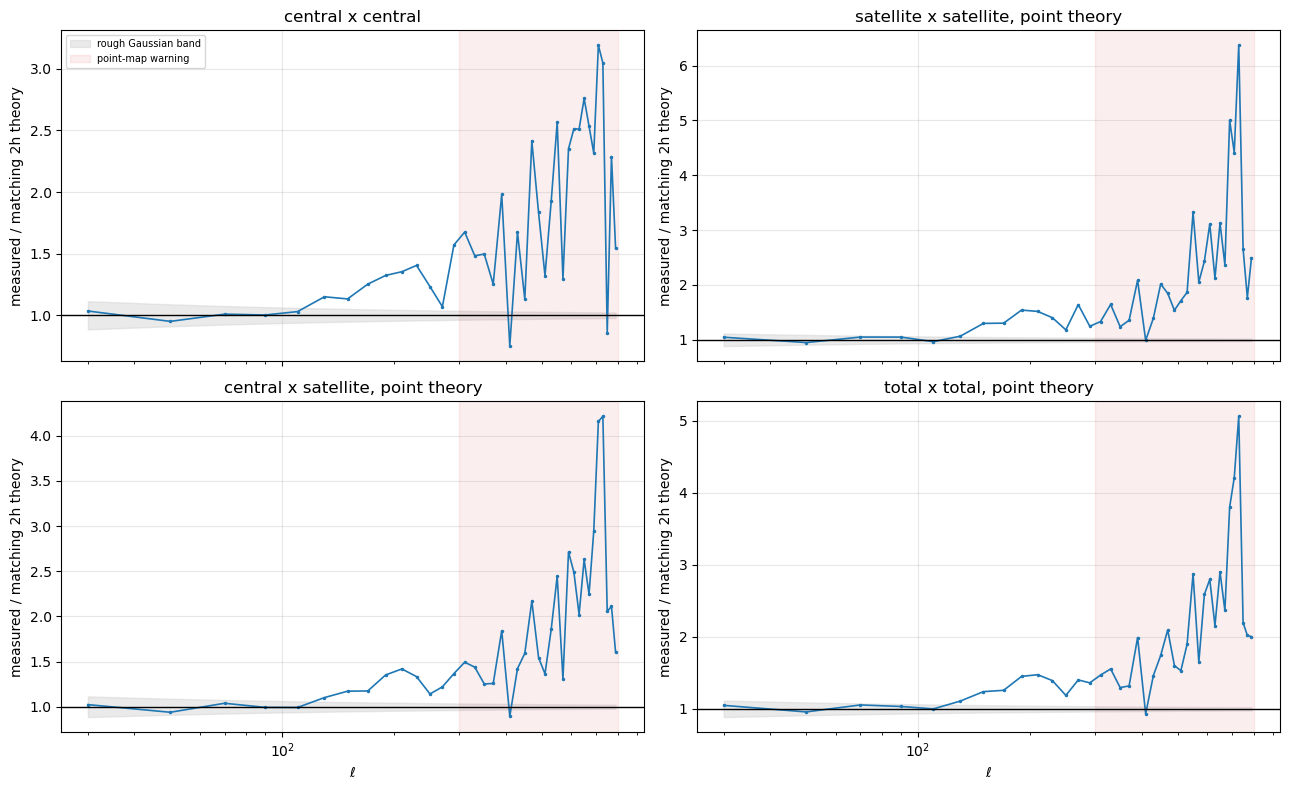

,diagnostic,ell_range,mean_ratio,sqrt_mean_ratio,n_ell
0,central x central,80-300,1.232395,1.081686,221
1,"satellite x satellite, point theory",80-300,1.288104,1.087707,221
2,"central x satellite, point theory",80-300,1.207394,1.070335,221
3,"total x total, point theory",80-300,1.262744,1.091196,221


In [4]:
weighted_cross = {
    'cen_cen': weighted_cls['ncen'],
    'sat_sat': weighted_cls['nsat'],
    'tot_tot': weighted_cls['ntot'],
    'cen_sat': agh.measure_catalog_weighted_cross_cls(halo_catalog, NSIDE_DIAG, hod_weights['ncen'], hod_weights['nsat'], z_range=z_range, lmax=ELL_MAX),
}

plot_specs = [
    ('cen_cen', 'cen_cen_u1', 'central x central'),
    ('sat_sat', 'sat_sat_u1', 'satellite x satellite, point theory'),
    ('cen_sat', 'cen_sat_u1', 'central x satellite, point theory'),
    ('tot_tot', 'tot_u1', 'total x total, point theory'),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, (meas_key, th_key, label) in zip(axes.ravel(), plot_specs):
    cls = weighted_cross[meas_key]
    cl = cls['cl_without_shot']
    ell = cls['ell']
    th = variant_2h['cls'][th_key]
    th_on = np.interp(ell, variant_2h['ell'], th, left=np.nan, right=np.nan)
    b = agh.bin_pair(ell, cl, th_on, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    err = agh.gaussian_ratio_error(b['ell'], delta_ell=DELTA_ELL, fsky=FSKY_GG)
    ax.plot(b['ell'], b['ratio'], marker='.', ms=3, lw=1.2)
    ax.fill_between(b['ell'], 1 - err, 1 + err, color='0.8', alpha=0.4, label='rough Gaussian band')
    ax.axhline(1.0, color='k', lw=1)
    ax.axvspan(POINTMAP_VALID_ELL[1], ELL_MAX, color='tab:red', alpha=0.08, label='point-map warning')
    ax.set_xscale('log')
    ax.set_title(label)
    ax.set_ylabel('measured / matching 2h theory')
    ax.grid(alpha=0.3)
axes[-1, 0].set_xlabel(r'$\ell$')
axes[-1, 1].set_xlabel(r'$\ell$')
axes[0, 0].legend(fontsize=7)
fig.tight_layout()
plt.show()

rows = []
for meas_key, th_key, label in plot_specs:
    cls = weighted_cross[meas_key]
    rows.append(mean_ratio_row(label, cls['ell'], cls['cl_without_shot'], variant_2h['cls'][th_key]))
decomp_summary_df = pd.DataFrame(rows)
display(decomp_summary_df)



## Mass Slices And Redshift Bookkeeping

The mass-slice ratios are meaningful because the map and theory still use the same broad lens window while masking the same mass interval.  Redshift sub-bin ratios are not plotted here: a sub-bin map has a different normalization from the broad top-hat theory unless the lens window is rebuilt for that sub-bin.  The redshift table below is only bookkeeping for where the HOD weight lives.


,diagnostic,ell_range,mean_ratio,sqrt_mean_ratio,n_ell,slice_type,lo,hi,weight,sum_weight
0,"ncen mass (14.0, 14.25)",80-300,1.253706,1.041279,221,mass,14.00,14.25,ncen,40192.437888
1,"nsat mass (14.0, 14.25)",80-300,1.278310,1.038533,221,mass,14.00,14.25,nsat,31122.802549
2,"ntot mass (14.0, 14.25)",80-300,1.258755,1.037560,221,mass,14.00,14.25,ntot,71315.240438
3,"ncen mass (14.25, 14.5)",80-300,1.141188,0.992588,221,mass,14.25,14.50,ncen,15384.197346
4,"nsat mass (14.25, 14.5)",80-300,1.171096,0.982732,221,mass,14.25,14.50,nsat,30623.865704
5,"ntot mass (14.25, 14.5)",80-300,1.159661,0.988441,221,mass,14.25,14.50,ntot,46008.063050
6,"ncen mass (14.5, 15.0)",80-300,1.601718,1.126446,221,mass,14.50,15.00,ncen,5243.436445
7,"nsat mass (14.5, 15.0)",80-300,1.728996,1.181621,221,mass,14.50,15.00,nsat,27319.530818
8,"ntot mass (14.5, 15.0)",80-300,1.709435,1.176895,221,mass,14.50,15.00,ntot,32562.967262
9,"ncen mass (15.0, 16.0)",80-300,-0.984343,1.867530,221,mass,15.00,16.00,ncen,145.754902


,z_lo,z_hi,overlap_with_lens_window,weight,n_parent_halos,sum_weight,effective_n_weighted,fraction_of_active_weight
0,0.25,0.35,0.075804,ncen,36155,28889.078086,31923.200257,0.473857
1,0.25,0.35,0.075804,nsat,36155,52773.519161,13296.537143,0.576665
2,0.25,0.35,0.075804,ntot,36155,81662.597247,20231.531606,0.535560
3,0.35,0.45,0.076864,ncen,48184,45253.554949,47570.948706,0.742277
4,0.35,0.45,0.076864,nsat,48184,55032.993359,18163.497314,0.601355
5,0.35,0.45,0.076864,ntot,48184,100286.548307,31640.774538,0.657699
6,0.45,0.50,0.000000,ncen,27058,25344.938404,26697.792456,0.415724
7,0.45,0.50,0.000000,nsat,27058,16350.463789,5979.299036,0.178664
8,0.45,0.50,0.000000,ntot,27058,41695.402193,17221.887742,0.273447


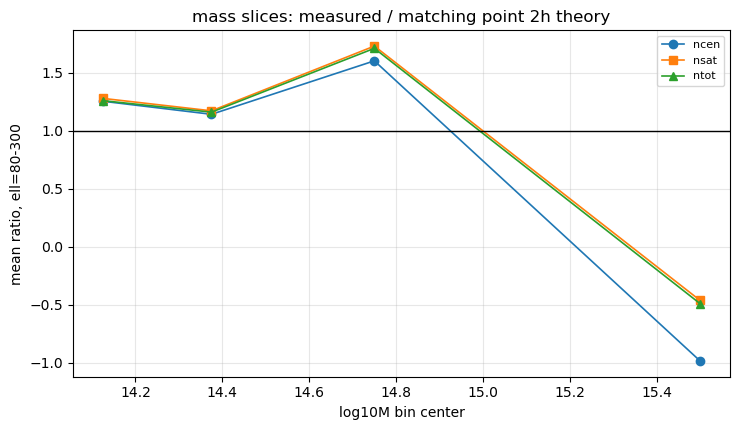

In [5]:

def masked_weight(base_weight, *, logm_range=None, z_slice=None):
    out = np.asarray(base_weight, dtype=np.float64).copy()
    mask = np.ones_like(out, dtype=bool)
    if logm_range is not None:
        logm = np.asarray(halo_catalog['log10M200c_hMsun'], dtype=np.float64)
        mask &= (logm >= logm_range[0]) & (logm < logm_range[1])
    if z_slice is not None:
        z = np.asarray(halo_catalog['z'], dtype=np.float64)
        mask &= (z >= z_slice[0]) & (z < z_slice[1])
    out[~mask] = 0.0
    return out

slice_rows = []
for mbin in MASS_BINS:
    v = agh.galaxy_2h_variant_cls(model_ref, COMPARE_BIN, logm_range=mbin)
    for wkey, th_key in [('ncen', 'cen_cen_u1'), ('nsat', 'sat_sat_u1'), ('ntot', 'tot_u1')]:
        cls = agh.measure_catalog_weighted_cls(halo_catalog, NSIDE_DIAG, masked_weight(hod_weights[wkey], logm_range=mbin), z_range=z_range, lmax=ELL_MAX)
        row = mean_ratio_row(f'{wkey} mass {mbin}', cls['ell'], cls['cl_without_shot'], v['cls'][th_key])
        row.update({'slice_type': 'mass', 'lo': mbin[0], 'hi': mbin[1], 'weight': wkey, 'sum_weight': cls['sumw']})
        slice_rows.append(row)

slice_df = pd.DataFrame(slice_rows)
display(slice_df)

redshift_rows = []
z_all = np.asarray(halo_catalog['z'], dtype=np.float64)
for zbin in Z_BINS_ACTIVE:
    overlap = max(0.0, min(zbin[1], z_range[1]) - max(zbin[0], z_range[0]))
    for wkey in ['ncen', 'nsat', 'ntot']:
        w = masked_weight(hod_weights[wkey], z_slice=zbin)
        active = (z_all >= zbin[0]) & (z_all < zbin[1]) & (w > 0)
        sumw = float(np.sum(w[active]))
        sumw2 = float(np.sum(w[active] ** 2))
        redshift_rows.append({
            'z_lo': zbin[0],
            'z_hi': zbin[1],
            'overlap_with_lens_window': overlap,
            'weight': wkey,
            'n_parent_halos': int(np.count_nonzero(active)),
            'sum_weight': sumw,
            'effective_n_weighted': sumw**2 / max(sumw2, 1.0e-30),
            'fraction_of_active_weight': sumw / max(float(np.sum(hod_weights[wkey][(z_all >= z_range[0]) & (z_all < z_range[1])])), 1.0e-30),
        })
redshift_bookkeeping_df = pd.DataFrame(redshift_rows)
display(redshift_bookkeeping_df)

fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.4))
for wkey, marker in [('ncen', 'o'), ('nsat', 's'), ('ntot', '^')]:
    ss = slice_df[slice_df['weight'] == wkey]
    x = 0.5 * (ss['lo'].to_numpy() + ss['hi'].to_numpy())
    ax.plot(x, ss['mean_ratio'], marker=marker, lw=1.2, label=wkey)
ax.axhline(1.0, color='k', lw=1)
ax.set_title('mass slices: measured / matching point 2h theory')
ax.set_xlabel('log10M bin center')
ax.set_ylabel(f'mean ratio, ell={POINTMAP_VALID_ELL[0]}-{POINTMAP_VALID_ELL[1]}')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Theory Surgery: Satellite `u(k|M,z)` Test

This checks whether the theory is suppressing satellite clustering through `u_clm(k|M,z)` more strongly than the parent-halo measurements support.  If `u=1` fixes the satellite/total ratios, focus on the Fourier satellite profile.  If ratios stay high even against `u=1`, focus on satellite-weighted halo bias or finite-realization clustering.


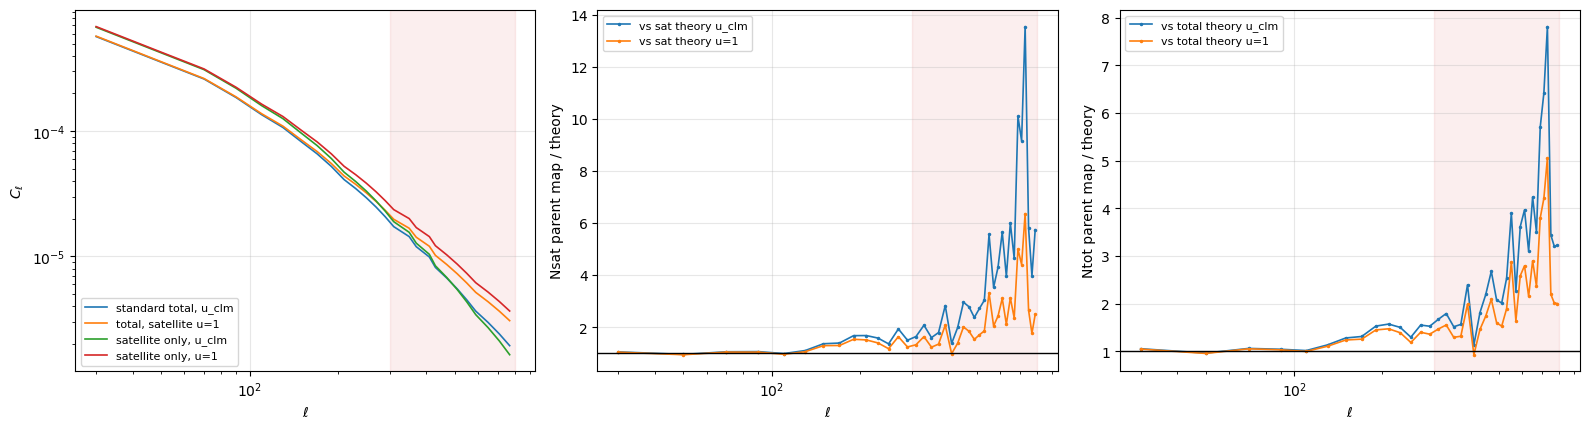

,diagnostic,ell_range,mean_ratio,sqrt_mean_ratio,n_ell
0,Nsat / sat u_clm,80-300,1.424112,1.141085,221
1,Nsat / sat u=1,80-300,1.288104,1.087707,221
2,Ntot / total u_clm,80-300,1.343165,1.124105,221
3,Ntot / total u=1,80-300,1.262744,1.091196,221


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharex=True)
curve_specs = [
    ('tot_std', 'standard total, u_clm'),
    ('tot_u1', 'total, satellite u=1'),
    ('sat_sat_u', 'satellite only, u_clm'),
    ('sat_sat_u1', 'satellite only, u=1'),
]
for key, label in curve_specs:
    b = psh.bin_spectrum(variant_2h['ell'], variant_2h['cls'][key], ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    axes[0].plot(b['ell'], b['value'], lw=1.2, label=label)

for th_key, label in [('sat_sat_u', 'vs sat theory u_clm'), ('sat_sat_u1', 'vs sat theory u=1')]:
    cls = weighted_cls['nsat']
    th_on = np.interp(cls['ell'], variant_2h['ell'], variant_2h['cls'][th_key], left=np.nan, right=np.nan)
    b = agh.bin_pair(cls['ell'], cls['cl_without_shot'], th_on, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    axes[1].plot(b['ell'], b['ratio'], marker='.', ms=3, lw=1.2, label=label)

for th_key, label in [('tot_std', 'vs total theory u_clm'), ('tot_u1', 'vs total theory u=1')]:
    cls = weighted_cls['ntot']
    th_on = np.interp(cls['ell'], variant_2h['ell'], variant_2h['cls'][th_key], left=np.nan, right=np.nan)
    b = agh.bin_pair(cls['ell'], cls['cl_without_shot'], th_on, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    axes[2].plot(b['ell'], b['ratio'], marker='.', ms=3, lw=1.2, label=label)

for ax in axes:
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
    ax.axvspan(POINTMAP_VALID_ELL[1], ELL_MAX, color='tab:red', alpha=0.08)
axes[0].set_yscale('log')
axes[1].axhline(1, color='k', lw=1)
axes[2].axhline(1, color='k', lw=1)
axes[0].set_ylabel(r'$C_\ell$')
axes[1].set_ylabel('Nsat parent map / theory')
axes[2].set_ylabel('Ntot parent map / theory')
for ax in axes:
    ax.set_xlabel(r'$\ell$')
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

surgery_rows = []
for meas_key, th_key, label in [
    ('nsat', 'sat_sat_u', 'Nsat / sat u_clm'),
    ('nsat', 'sat_sat_u1', 'Nsat / sat u=1'),
    ('ntot', 'tot_std', 'Ntot / total u_clm'),
    ('ntot', 'tot_u1', 'Ntot / total u=1'),
]:
    cls = weighted_cls[meas_key]
    surgery_rows.append(mean_ratio_row(label, cls['ell'], cls['cl_without_shot'], variant_2h['cls'][th_key]))
surgery_df = pd.DataFrame(surgery_rows)
display(surgery_df)


## Effective Satellite Bias

The theory-side bias arrays show how the HOD weights and satellite profile affect large-scale bias.  The empirical ratios below estimate whether the measured parent-halo field has excess bias beyond the point-satellite theory.


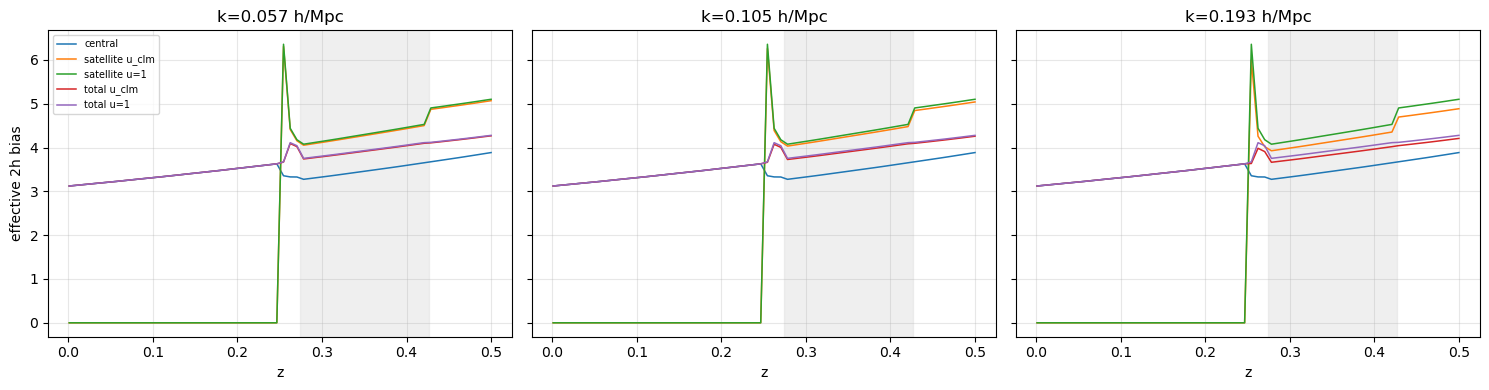

,field,mean_cl_ratio,mean_bias_ratio,rough_cv_sigma_ratio
0,central,1.229305,1.106251,0.048054
1,satellite point,1.292457,1.133136,0.048054
2,total point,1.263622,1.121823,0.048054


In [7]:
k_grid = np.asarray(model_ref.pkz.kPk_array, dtype=np.float64)
z_model = np.asarray(model_ref.base.z_array, dtype=np.float64)
k_show = [0.05, 0.1, 0.2]
fig, axes = plt.subplots(1, len(k_show), figsize=(15, 4), sharey=True)
for ax, kval in zip(axes, k_show):
    ik = int(np.argmin(np.abs(k_grid - kval)))
    for key, label in [('cen_self', 'central'), ('sat_u_self', 'satellite u_clm'), ('sat_u1_self', 'satellite u=1'), ('tot_std', 'total u_clm'), ('tot_u1', 'total u=1')]:
        bias_arr = np.asarray(variant_2h['bias'][key], dtype=np.float64)
        bias_z = bias_arr[min(ik, bias_arr.shape[0] - 1)]
        ax.plot(z_model, bias_z, lw=1.1, label=label)
    ax.axvspan(z_range[0], z_range[1], color='0.85', alpha=0.4)
    ax.set_title(f'k={k_grid[ik]:.3f} h/Mpc')
    ax.set_xlabel('z')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('effective 2h bias')
axes[0].legend(fontsize=7)
fig.tight_layout()
plt.show()

bias_rows = []
for meas_key, th_key, label in [
    ('ncen', 'cen_cen_u1', 'central'),
    ('nsat', 'sat_sat_u1', 'satellite point'),
    ('ntot', 'tot_u1', 'total point'),
]:
    cls = weighted_cls[meas_key]
    th_on = np.interp(cls['ell'], variant_2h['ell'], variant_2h['cls'][th_key], left=np.nan, right=np.nan)
    b = agh.bin_pair(cls['ell'], cls['cl_without_shot'], th_on, ell_min=POINTMAP_VALID_ELL[0], ell_max=POINTMAP_VALID_ELL[1], delta_ell=DELTA_ELL)
    err = agh.gaussian_ratio_error(b['ell'], delta_ell=DELTA_ELL, fsky=FSKY_GG)
    bias_rows.append({
        'field': label,
        'mean_cl_ratio': float(np.nanmean(b['ratio'])),
        'mean_bias_ratio': float(np.nanmean(np.sqrt(np.clip(b['ratio'], 0, np.inf)))),
        'rough_cv_sigma_ratio': float(np.nanmean(err)),
    })
bias_df = pd.DataFrame(bias_rows)
display(bias_df)



## Empirical Halo Bias Against Abacus Particle-Shell Matter

This is the key simulation-side cross-check.  We build a projected matter overdensity map from the Abacus total `heal-counts` shells, using the same broad lens redshift window as the parent-halo maps.  Then we measure `C_hm/C_mm` for the central-, satellite-, and total-weighted parent-halo fields.  If this empirical bias is high by the same amount as `gg`, the problem is not satellite placement; it is the effective halo-bias/projection model or this particular lightcone realization.


[1/14] loading/downsampling Step0722-0727, lens weight=1.5837e-03
[2/14] loading/downsampling Step0728-0734, lens weight=7.2571e-02
[3/14] loading/downsampling Step0735-0740, lens weight=7.4737e-02
[4/14] loading/downsampling Step0741-0747, lens weight=8.8047e-02
[5/14] loading/downsampling Step0748-0753, lens weight=7.2415e-02
[6/14] loading/downsampling Step0754-0760, lens weight=8.2104e-02
[7/14] loading/downsampling Step0761-0767, lens weight=7.9294e-02
[8/14] loading/downsampling Step0768-0774, lens weight=8.0882e-02
[9/14] loading/downsampling Step0775-0781, lens weight=7.9235e-02
[10/14] loading/downsampling Step0782-0788, lens weight=7.8229e-02
[11/14] loading/downsampling Step0789-0795, lens weight=7.6193e-02
[12/14] loading/downsampling Step0796-0802, lens weight=7.6992e-02
[13/14] loading/downsampling Step0803-0809, lens weight=7.2426e-02
[14/14] loading/downsampling Step0810-0817, lens weight=3.8971e-02
matter cache: cache-miss-built /mnt/ceph/users/spandey/ltu-godmax/GODMA

,step_id,z_lo,z_hi,weight_raw,mean_counts_1024_or_512,cache_path,input_count_sum,output_count_sum,weight_normalized
0,Step0722-0727,0.424893,0.437067,0.001584,3359.411804,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,1.056780e+10,1.056780e+10,0.001626
1,Step0728-0734,0.411525,0.424893,0.072571,3538.218372,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,1.113027e+10,1.113027e+10,0.074533
2,Step0735-0740,0.400115,0.411525,0.074737,2881.443906,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,9.064239e+09,9.064239e+09,0.076758
3,Step0741-0747,0.386673,0.400115,0.088047,3240.102974,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,1.019248e+10,1.019248e+10,0.090427
4,Step0748-0753,0.375617,0.386673,0.072415,2526.907414,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,7.948963e+09,7.948963e+09,0.074372
5,Step0754-0760,0.363083,0.375617,0.082104,2721.193412,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,8.560134e+09,8.560134e+09,0.084323
6,Step0761-0767,0.350977,0.363083,0.079294,2485.893219,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,7.819944e+09,7.819944e+09,0.081437
7,Step0768-0774,0.338629,0.350977,0.080882,2398.617839,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,7.545399e+09,7.545399e+09,0.083069
8,Step0775-0781,0.326532,0.338629,0.079235,2211.545489,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,6.956921e+09,6.956921e+09,0.081377
9,Step0782-0788,0.314589,0.326532,0.078229,2056.806275,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,6.470153e+09,6.470153e+09,0.080344


matter delta mean/std/min/max: -4.0745362639427185e-10 0.4033398926258087 -0.6733459234237671 12.445100784301758


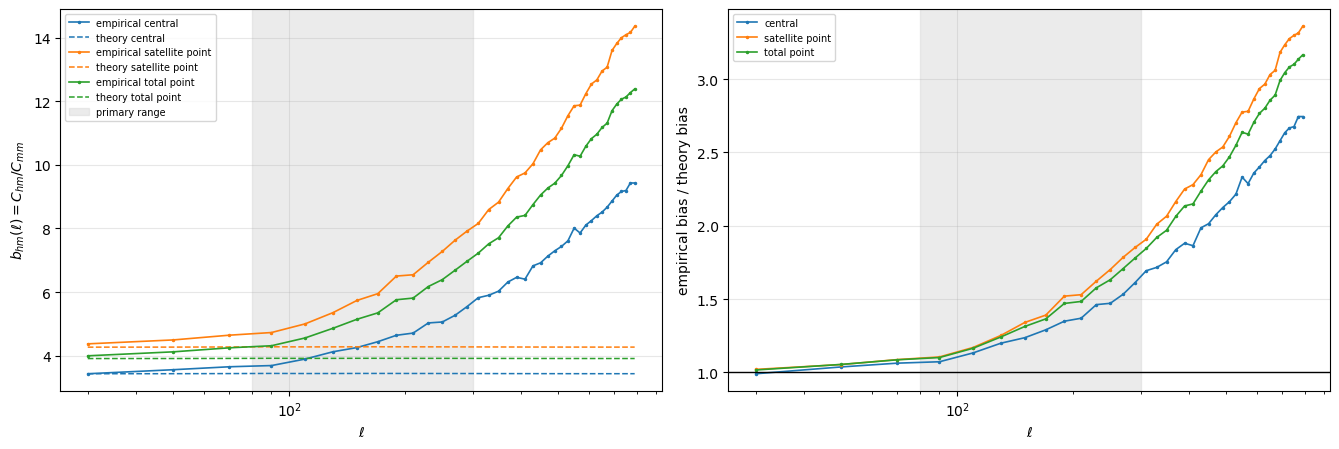

,field,mean_empirical_bias,mean_theory_bias,mean_empirical_over_theory,n_bins
0,central,4.606070,3.441555,1.338393,11
1,satellite point,6.325946,4.278684,1.478512,11
2,total point,5.638295,3.917717,1.439202,11


In [8]:

TOTAL_HEALPIX_ROOT = Path('/mnt/ceph/users/backlight/AbacusBacklight_base_c9999_ph9999/lightcone_healpix/total')
MATTER_CACHE = CACHE_ROOT / f'projected_matter_delta_nside{NSIDE_DIAG}_z{z_range[0]:.4f}_{z_range[1]:.4f}.h5'
OVERWRITE_MATTER_CACHE = False

def shell_lens_overlap_weight(meta, z_grid, nz_window):
    zlo = max(float(meta['z_lo']), float(z_range[0]))
    zhi = min(float(meta['z_hi']), float(z_range[1]))
    if zhi <= zlo:
        return 0.0
    samples = np.linspace(zlo, zhi, 32)
    w = np.interp(samples, z_grid, nz_window, left=0.0, right=0.0)
    return float(np.trapz(w, samples))

def build_or_load_projected_matter_delta():
    if MATTER_CACHE.exists() and not OVERWRITE_MATTER_CACHE:
        with h5py.File(MATTER_CACHE, 'r') as handle:
            matter_delta = handle['matter_delta'][:]
            shell_table = pd.DataFrame(json.loads(handle.attrs['shell_table_json']))
        return matter_delta, shell_table, 'cache-hit'

    shells_all = psh.discover_total_shells(TOTAL_HEALPIX_ROOT, z_max_hint=z_range[1] + 0.05)
    shells = psh.select_shells(shells_all, z_range[0], z_range[1])
    if not shells:
        raise RuntimeError(f'No total particle shells overlap z_range={z_range}')
    shell_cache_root = psh.particle_shell_cache_root(cfg, NSIDE_DIAG)
    matter_delta = np.zeros(hp.nside2npix(NSIDE_DIAG), dtype=np.float64)
    rows = []
    total_weight = 0.0
    for i, meta in enumerate(shells, 1):
        weight = shell_lens_overlap_weight(meta, z_grid_lens, z_tophat)
        if weight <= 0:
            continue
        print(f'[{i}/{len(shells)}] loading/downsampling {meta["step_id"]}, lens weight={weight:.4e}')
        cache_path = psh.read_or_create_downgraded_shell_cache(meta, NSIDE_DIAG, shell_cache_root, overwrite=False, batch_parent_pixels=32_768)
        data, attrs = psh.load_downgraded_shell_cache(cache_path, NSIDE_DIAG)
        counts = np.asarray(data['counts'], dtype=np.float64)
        mean_counts = float(np.mean(counts))
        if mean_counts <= 0:
            continue
        matter_delta += weight * (counts / mean_counts - 1.0)
        total_weight += weight
        rows.append({
            'step_id': meta['step_id'],
            'z_lo': float(meta['z_lo']),
            'z_hi': float(meta['z_hi']),
            'weight_raw': weight,
            'mean_counts_1024_or_512': mean_counts,
            'cache_path': str(cache_path),
            'input_count_sum': float(attrs.get('input_count_sum', np.nan)),
            'output_count_sum': float(attrs.get('output_count_sum', np.nan)),
        })
    if total_weight <= 0:
        raise RuntimeError('Projected matter-shell lens weights summed to zero.')
    matter_delta = matter_delta / total_weight
    matter_delta = matter_delta - np.mean(matter_delta)
    for row in rows:
        row['weight_normalized'] = row['weight_raw'] / total_weight
    MATTER_CACHE.parent.mkdir(parents=True, exist_ok=True)
    with h5py.File(MATTER_CACHE, 'w') as handle:
        handle.create_dataset('matter_delta', data=matter_delta.astype(np.float32), compression='lzf', shuffle=True)
        handle.attrs['z_range'] = np.asarray(z_range, dtype=np.float64)
        handle.attrs['nside'] = int(NSIDE_DIAG)
        handle.attrs['source_root'] = str(TOTAL_HEALPIX_ROOT)
        handle.attrs['shell_table_json'] = json.dumps(rows)
        handle.attrs['window'] = 'same top-hat lens dN/dz used by this notebook'
    return matter_delta.astype(np.float32), pd.DataFrame(rows), 'cache-miss-built'

import json
matter_delta, matter_shell_df, matter_cache_status = build_or_load_projected_matter_delta()
print('matter cache:', matter_cache_status, MATTER_CACHE)
display(matter_shell_df)
print('matter delta mean/std/min/max:', float(np.mean(matter_delta)), float(np.std(matter_delta)), float(np.min(matter_delta)), float(np.max(matter_delta)))

matter_auto = agh.measure_delta_map_cls(matter_delta, NSIDE_DIAG, lmax=ELL_MAX)
hm_measured = {
    'ncen': agh.measure_delta_map_cls(weighted_cls['ncen']['delta'], NSIDE_DIAG, delta_b=matter_delta, lmax=ELL_MAX),
    'nsat': agh.measure_delta_map_cls(weighted_cls['nsat']['delta'], NSIDE_DIAG, delta_b=matter_delta, lmax=ELL_MAX),
    'ntot': agh.measure_delta_map_cls(weighted_cls['ntot']['delta'], NSIDE_DIAG, delta_b=matter_delta, lmax=ELL_MAX),
}
gm_theory = agh.galaxy_matter_2h_variant_cls(model_ref, COMPARE_BIN, matter_power='total')

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharex=True)
plot_bias_specs = [
    ('ncen', 'cen', 'central', 'tab:blue'),
    ('nsat', 'sat_u1', 'satellite point', 'tab:orange'),
    ('ntot', 'tot_u1', 'total point', 'tab:green'),
]
for map_key, theory_key, label, color in plot_bias_specs:
    ell = hm_measured[map_key]['ell']
    emp_bias = np.divide(hm_measured[map_key]['cl'], matter_auto['cl'], out=np.full_like(hm_measured[map_key]['cl'], np.nan), where=np.abs(matter_auto['cl']) > 0)
    th_bias = np.interp(ell, gm_theory['ell'], gm_theory['bias'][theory_key], left=np.nan, right=np.nan)
    b_emp = psh.bin_spectrum(ell, emp_bias, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    b_th = psh.bin_spectrum(ell, th_bias, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    axes[0].plot(b_emp['ell'], b_emp['value'], marker='.', ms=3, lw=1.2, color=color, label=f'empirical {label}')
    axes[0].plot(b_th['ell'], b_th['value'], lw=1.1, ls='--', color=color, label=f'theory {label}')
    bp = psh.bin_spectrum_pair(ell, emp_bias, th_bias, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    axes[1].plot(bp['ell'], bp['ratio'], marker='.', ms=3, lw=1.2, color=color, label=label)
for ax in axes:
    ax.axvspan(POINTMAP_VALID_ELL[0], POINTMAP_VALID_ELL[1], color='0.85', alpha=0.5, label='primary range' if ax is axes[0] else None)
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r'$b_{hm}(\ell)=C_{hm}/C_{mm}$')
axes[1].set_ylabel('empirical bias / theory bias')
axes[1].axhline(1.0, color='k', lw=1)
for ax in axes:
    ax.set_xlabel(r'$\ell$')
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

matter_bias_rows = []
for map_key, theory_key, label, _ in plot_bias_specs:
    ell = hm_measured[map_key]['ell']
    emp_bias = np.divide(hm_measured[map_key]['cl'], matter_auto['cl'], out=np.full_like(hm_measured[map_key]['cl'], np.nan), where=np.abs(matter_auto['cl']) > 0)
    th_bias = np.interp(ell, gm_theory['ell'], gm_theory['bias'][theory_key], left=np.nan, right=np.nan)
    bp = psh.bin_spectrum_pair(ell, emp_bias, th_bias, ell_min=POINTMAP_VALID_ELL[0], ell_max=POINTMAP_VALID_ELL[1], delta_ell=DELTA_ELL)
    matter_bias_rows.append({
        'field': label,
        'mean_empirical_bias': float(np.nanmean(bp['value_a'])),
        'mean_theory_bias': float(np.nanmean(bp['value_b'])),
        'mean_empirical_over_theory': float(np.nanmean(bp['ratio'])),
        'n_bins': int(len(bp['ell'])),
    })
matter_bias_df = pd.DataFrame(matter_bias_rows)
display(matter_bias_df)



## Matched-Window Particle-Shell Bias Check

The previous particle-shell comparison intentionally used the broad top-hat lens window.  That is not the exact window of a projected parent-halo map: the map weights each redshift by the actual HOD-weighted parent abundance.  This cell builds one matter projection per parent field using the same shell-by-shell `Ncen`, `Nsat`, or `Ntot` weights, then projects the theory with the matching measured parent `dN/dz`.


,step_id,z_lo,z_hi,tophat_weight_norm,ncen_shell_weight_norm,nsat_shell_weight_norm,ntot_shell_weight_norm
0,Step0722-0727,0.424893,0.437067,0.001626,0.016102,0.010358,0.012655
1,Step0728-0734,0.411525,0.424893,0.074533,0.102748,0.088807,0.094381
2,Step0735-0740,0.400115,0.411525,0.076758,0.086745,0.077965,0.081475
3,Step0741-0747,0.386673,0.400115,0.090427,0.099555,0.093164,0.095719
4,Step0748-0753,0.375617,0.386673,0.074372,0.080082,0.075507,0.077336
5,Step0754-0760,0.363083,0.375617,0.084323,0.089461,0.085985,0.087375
6,Step0761-0767,0.350977,0.363083,0.081437,0.080402,0.078703,0.079382
7,Step0768-0774,0.338629,0.350977,0.083069,0.079938,0.079420,0.079627
8,Step0775-0781,0.326532,0.338629,0.081377,0.073672,0.076372,0.075292
9,Step0782-0788,0.314589,0.326532,0.080344,0.070330,0.076637,0.074115


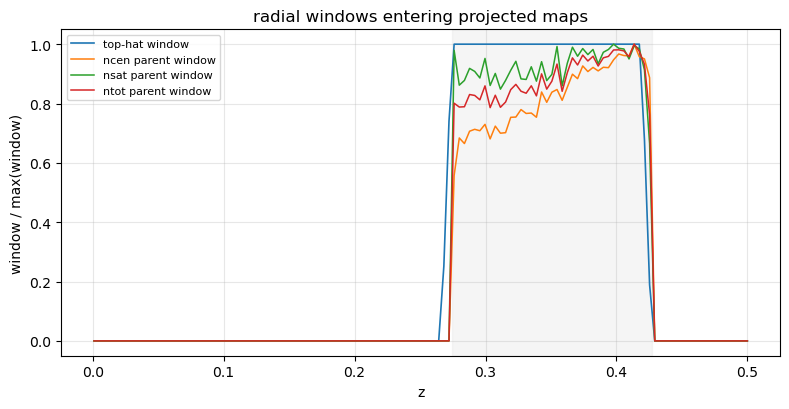

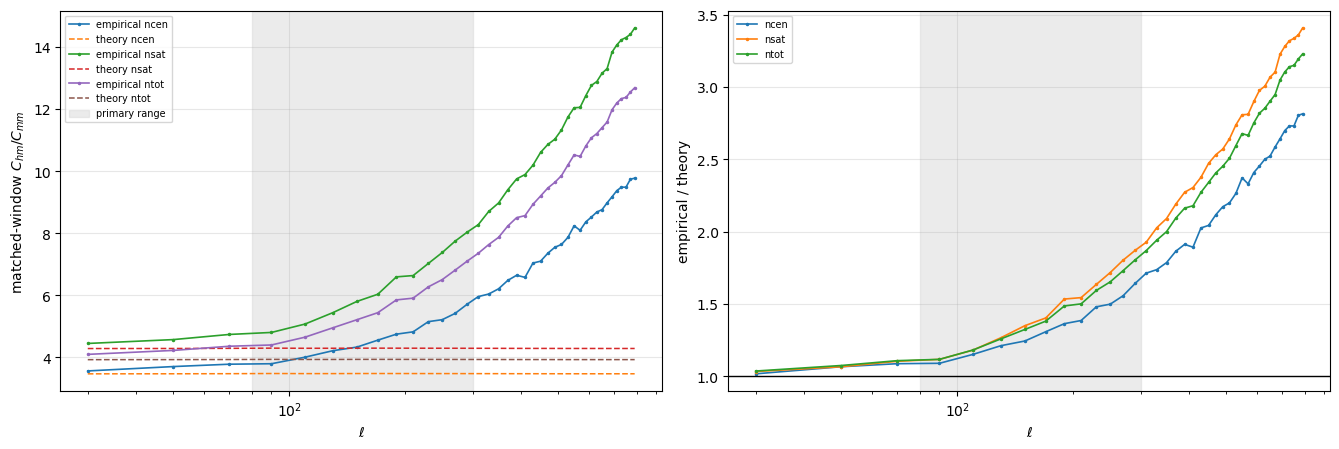

,field,theory_bias_curve,mean_empirical_bias,mean_theory_bias,mean_empirical_over_theory,n_bins
0,ncen,cen,4.726823,3.480131,1.358255,11
1,nsat,sat_u1,6.418564,4.297326,1.493652,11
2,ntot,tot_u1,5.739791,3.936361,1.458172,11


In [15]:

z_cls = np.asarray(model_ref.cls.z_array_for_Cls, dtype=np.float64)
z_halo = np.asarray(halo_catalog['z'], dtype=np.float64)

parent_weight_keys = [('ncen', 'cen'), ('nsat', 'sat_u1'), ('ntot', 'tot_u1')]

def parent_nz_on_cls_grid(weight_key):
    weights = np.asarray(hod_weights[weight_key], dtype=np.float64)
    valid = (z_halo >= z_range[0]) & (z_halo < z_range[1]) & np.isfinite(weights) & (weights > 0)
    dz = float(np.median(np.diff(z_cls)))
    edges = np.concatenate(([z_cls[0] - 0.5 * dz], 0.5 * (z_cls[1:] + z_cls[:-1]), [z_cls[-1] + 0.5 * dz]))
    hist, _ = np.histogram(z_halo[valid], bins=edges, weights=weights[valid])
    return agh.normalize_nz(z_cls, hist)

def parent_shell_weight(weight_key, zlo, zhi):
    weights = np.asarray(hod_weights[weight_key], dtype=np.float64)
    lo = max(float(zlo), float(z_range[0]))
    hi = min(float(zhi), float(z_range[1]))
    if hi <= lo:
        return 0.0
    mask = (z_halo >= lo) & (z_halo < hi) & np.isfinite(weights) & (weights > 0)
    return float(np.sum(weights[mask]))

parent_nz = {key: parent_nz_on_cls_grid(key) for key, _ in parent_weight_keys}
parent_shell_rows = []
parent_matter_delta = {key: np.zeros(hp.nside2npix(NSIDE_DIAG), dtype=np.float64) for key, _ in parent_weight_keys}
parent_shell_weight_sums = {key: 0.0 for key, _ in parent_weight_keys}

for row in matter_shell_df.itertuples(index=False):
    cache_path = getattr(row, 'cache_path')
    data, _ = psh.load_downgraded_shell_cache(cache_path, NSIDE_DIAG)
    counts = np.asarray(data['counts'], dtype=np.float64)
    shell_delta = counts / max(float(np.mean(counts)), 1.0e-30) - 1.0
    out_row = {'step_id': row.step_id, 'z_lo': float(row.z_lo), 'z_hi': float(row.z_hi), 'tophat_weight_norm': float(row.weight_normalized)}
    for key, _ in parent_weight_keys:
        sw = parent_shell_weight(key, row.z_lo, row.z_hi)
        out_row[f'{key}_shell_weight_raw'] = sw
        if sw > 0:
            parent_matter_delta[key] += sw * shell_delta
            parent_shell_weight_sums[key] += sw
    parent_shell_rows.append(out_row)

for key, _ in parent_weight_keys:
    if parent_shell_weight_sums[key] <= 0:
        raise RuntimeError(f'No parent shell weight for {key}')
    parent_matter_delta[key] = parent_matter_delta[key] / parent_shell_weight_sums[key]
    parent_matter_delta[key] = (parent_matter_delta[key] - np.mean(parent_matter_delta[key])).astype(np.float32)

parent_shell_weight_df = pd.DataFrame(parent_shell_rows)
for key, _ in parent_weight_keys:
    parent_shell_weight_df[f'{key}_shell_weight_norm'] = parent_shell_weight_df[f'{key}_shell_weight_raw'] / max(parent_shell_weight_sums[key], 1.0e-30)
display(parent_shell_weight_df[['step_id', 'z_lo', 'z_hi', 'tophat_weight_norm', 'ncen_shell_weight_norm', 'nsat_shell_weight_norm', 'ntot_shell_weight_norm']])

fig, ax = plt.subplots(1, 1, figsize=(8, 4.2))
z_tophat_cls = np.interp(z_cls, z_grid_lens, z_tophat, left=0.0, right=0.0)
ax.plot(z_cls, z_tophat_cls / max(np.nanmax(z_tophat_cls), 1.0e-30), lw=1.2, label='top-hat window')
for key, _ in parent_weight_keys:
    ax.plot(z_cls, parent_nz[key] / max(np.nanmax(parent_nz[key]), 1.0e-30), lw=1.1, label=f'{key} parent window')
ax.axvspan(z_range[0], z_range[1], color='0.9', alpha=0.4)
ax.set_xlabel('z')
ax.set_ylabel('window / max(window)')
ax.set_title('radial windows entering projected maps')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

matched_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharex=True)
for key, theory_key in parent_weight_keys:
    matter_auto_k = agh.measure_delta_map_cls(parent_matter_delta[key], NSIDE_DIAG, lmax=ELL_MAX)
    hm_k = agh.measure_delta_map_cls(weighted_cls[key]['delta'], NSIDE_DIAG, delta_b=parent_matter_delta[key], lmax=ELL_MAX)
    emp_bias = np.divide(hm_k['cl'], matter_auto_k['cl'], out=np.full_like(hm_k['cl'], np.nan), where=np.abs(matter_auto_k['cl']) > 0)
    th = agh.galaxy_matter_bias_curves_with_window(model_ref, variant_2h['bias'], parent_nz[key], z_window_grid=z_cls, matter_power='total')
    th_bias = np.interp(hm_k['ell'], th['ell'], th['bias'][theory_key], left=np.nan, right=np.nan)
    b_emp = psh.bin_spectrum(hm_k['ell'], emp_bias, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    b_th = psh.bin_spectrum(hm_k['ell'], th_bias, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    bp = psh.bin_spectrum_pair(hm_k['ell'], emp_bias, th_bias, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    axes[0].plot(b_emp['ell'], b_emp['value'], marker='.', ms=3, lw=1.2, label=f'empirical {key}')
    axes[0].plot(b_th['ell'], b_th['value'], lw=1.1, ls='--', label=f'theory {key}')
    axes[1].plot(bp['ell'], bp['ratio'], marker='.', ms=3, lw=1.2, label=key)
    train = psh.bin_spectrum_pair(hm_k['ell'], emp_bias, th_bias, ell_min=POINTMAP_VALID_ELL[0], ell_max=POINTMAP_VALID_ELL[1], delta_ell=DELTA_ELL)
    matched_rows.append({
        'field': key,
        'theory_bias_curve': theory_key,
        'mean_empirical_bias': float(np.nanmean(train['value_a'])),
        'mean_theory_bias': float(np.nanmean(train['value_b'])),
        'mean_empirical_over_theory': float(np.nanmean(train['ratio'])),
        'n_bins': int(len(train['ell'])),
    })
for ax in axes:
    ax.axvspan(POINTMAP_VALID_ELL[0], POINTMAP_VALID_ELL[1], color='0.85', alpha=0.5, label='primary range' if ax is axes[0] else None)
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r'matched-window $C_{hm}/C_{mm}$')
axes[1].set_ylabel('empirical / theory')
axes[1].axhline(1.0, color='k', lw=1)
for ax in axes:
    ax.set_xlabel(r'$\ell$')
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()
matched_window_bias_df = pd.DataFrame(matched_rows)
display(matched_window_bias_df)


## Satellite Placement And Profile Checks

These checks ask a different question: once satellites are generated, are their projected radii consistent with the CDF used in `get_sim_maps.py`?  This cannot explain a large-scale parent-halo excess by itself, but it can explain a small-scale `gg` mismatch or a wrong `u_sat(k)` theory correction.


,n_halos,n_unique_halo_keys,n_colliding_halo_keys,max_halos_per_key,n_satellites,n_unique_satellite_keys,n_unmatched_satellite_keys,n_ambiguous_satellite_keys,max_halos_per_satellite_key
0,140661,140642,18,3,117524,54527,0,12,2


parent matching finished in 3.4s


,n_satellites,n_matched,n_unmatched,n_ambiguous
0,117524,117524,0,34


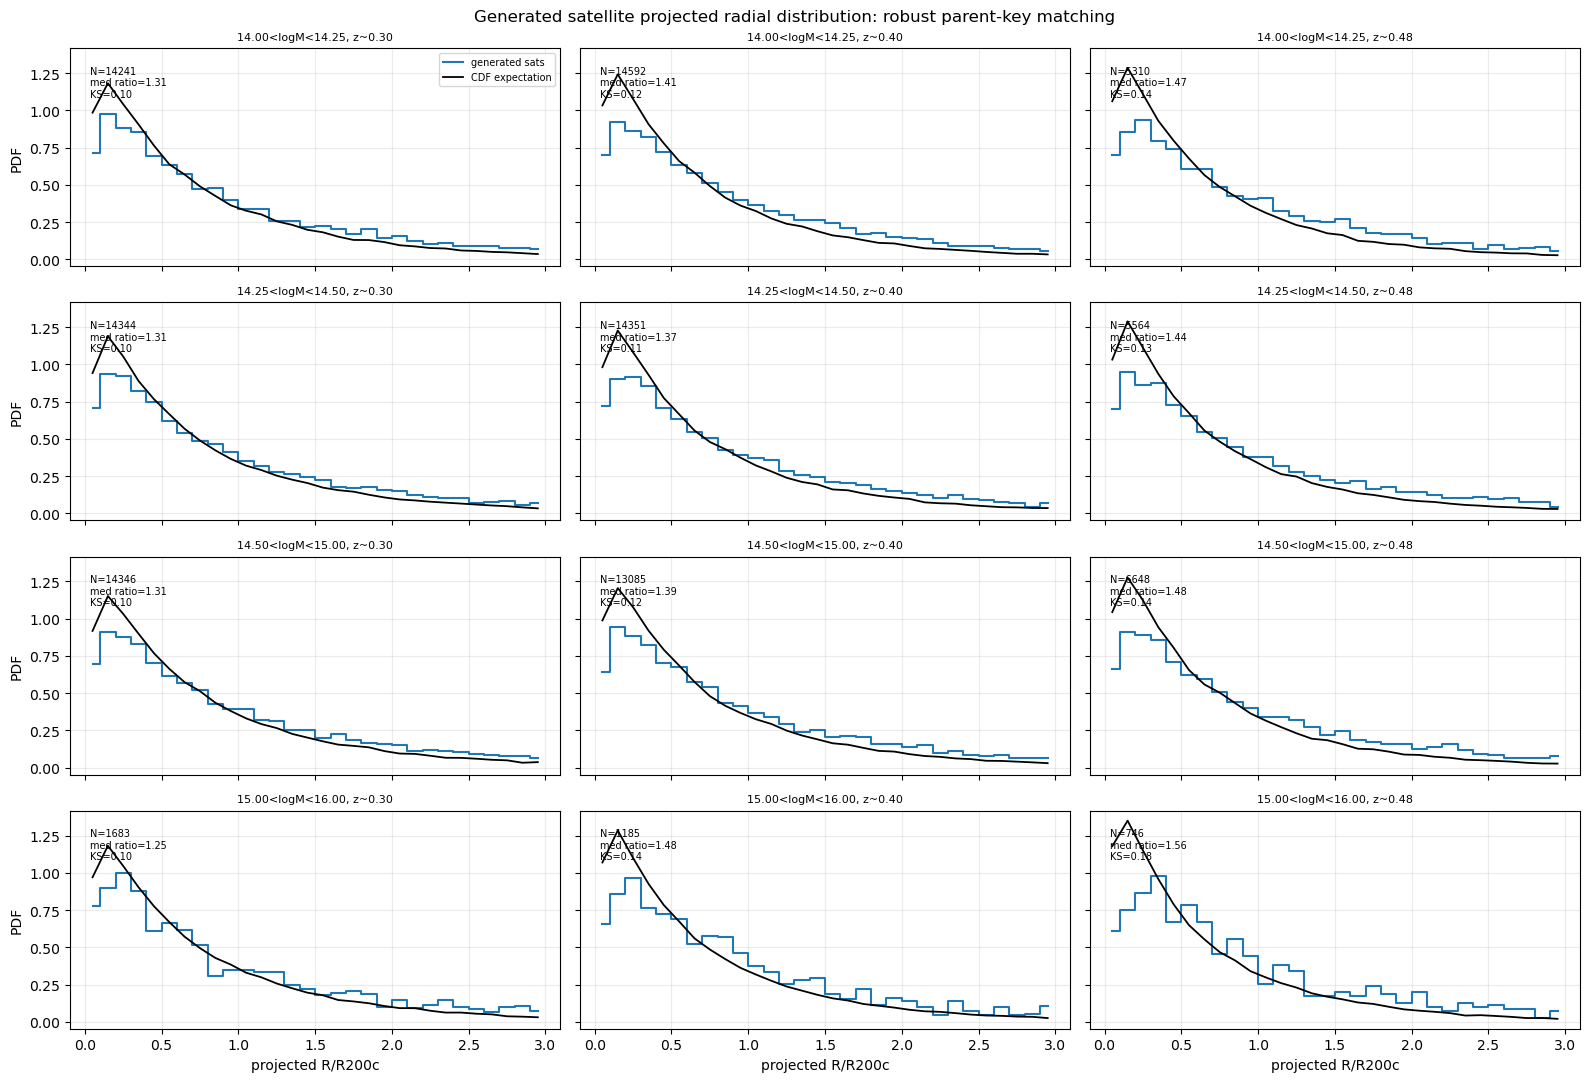

,logM_lo,logM_hi,z_center,n_sat,n_obs,median_ratio,q68_ratio,ks_distance
0,14.00,14.25,0.30,14241,14241,1.311206,1.310037,0.097434
1,14.00,14.25,0.40,14592,14592,1.412999,1.407419,0.124284
2,14.00,14.25,0.48,5310,5310,1.472843,1.487505,0.144571
3,14.25,14.50,0.30,14344,14344,1.310075,1.311232,0.097165
4,14.25,14.50,0.40,14351,14351,1.369093,1.369828,0.114849
5,14.25,14.50,0.48,5564,5564,1.437492,1.450969,0.132444
6,14.50,15.00,0.30,14346,14346,1.311877,1.321270,0.101860
7,14.50,15.00,0.40,13085,13085,1.390140,1.387156,0.121431
8,14.50,15.00,0.48,6648,6648,1.483003,1.494336,0.143597
9,15.00,16.00,0.30,1683,1683,1.249136,1.337333,0.104178


In [9]:
key_summary = agh.parent_key_collision_summary(halo_catalog, galaxies)
display(pd.DataFrame([key_summary]))

t0 = time.perf_counter()
parent_match = agh.match_satellites_to_parent_halos(galaxies, halo_catalog)
print(f'parent matching finished in {time.perf_counter() - t0:.1f}s')
display(pd.DataFrame([{k: v for k, v in parent_match.items() if isinstance(v, (int, float, np.integer, np.floating))}]))

profile_rows = []
fig, axes = plt.subplots(len(MASS_BINS), len(PROFILE_Z_CENTERS), figsize=(16, 11), sharex=True, sharey=True)
for im, mbin in enumerate(MASS_BINS):
    for iz, zc in enumerate(PROFILE_Z_CENTERS):
        ax = axes[im, iz]
        zbin = (max(0.0, zc - PROFILE_Z_HALF_WIDTH), min(0.5, zc + PROFILE_Z_HALF_WIDTH))
        obs = agh.stack_satellites_by_parent_key(galaxies, halo_catalog, parent_match, PROFILE_RADIAL_EDGES_R200, logm_range=mbin, z_range=zbin)
        logm_mid = 0.5 * (mbin[0] + min(mbin[1], 15.6))
        exp = agh.expected_projected_satellite_hist(model_ref, logm=logm_mid, z=zc, radial_edges_r200=PROFILE_RADIAL_EDGES_R200, n_samples=PROFILE_EXPECTED_SAMPLES, seed=8100 + 10 * im + iz, include_samples=True)
        metrics = agh.radial_distribution_metrics(obs['rr200'], exp['rr200'])
        profile_rows.append({'logM_lo': mbin[0], 'logM_hi': mbin[1], 'z_center': zc, 'n_sat': obs['n_sat_matched'], **metrics})
        if obs['n_sat_matched'] == 0:
            ax.text(0.5, 0.5, 'empty / outside active occupation', ha='center', va='center', transform=ax.transAxes, fontsize=8)
        else:
            ax.step(obs['r_mid'], obs['pdf'], where='mid', label='generated sats')
            ax.plot(exp['r_mid'], exp['pdf'], color='k', lw=1.3, label='CDF expectation')
            ax.text(0.04, 0.92, f'N={obs["n_sat_matched"]}\nmed ratio={metrics["median_ratio"]:.2f}\nKS={metrics["ks_distance"]:.2f}', transform=ax.transAxes, fontsize=7, va='top')
        ax.set_title(f'{mbin[0]:.2f}<logM<{mbin[1]:.2f}, z~{zc:.2f}', fontsize=8)
        ax.grid(alpha=0.25)
        if im == len(MASS_BINS) - 1:
            ax.set_xlabel('projected R/R200c')
        if iz == 0:
            ax.set_ylabel('PDF')
axes[0, 0].legend(fontsize=7)
fig.suptitle('Generated satellite projected radial distribution: robust parent-key matching')
fig.tight_layout()
plt.show()
profile_df = pd.DataFrame(profile_rows)
display(profile_df)



## Radius Convention Check

The first radial stack used the catalog `DA_hMpc` and `R200c_hMpc` columns to convert angles into `R/R200c`.  This cell recomputes the same satellite radii using GODMAX-interpolated `DA` and `R200c`.  If the catalog-geometry median ratio is high but the GODMAX-geometry median ratio moves near unity, the apparent satellite-radius mismatch is a convention mismatch in the diagnostic, not necessarily a placement bug.


,quantity,n_active,q01,q05,q16,q50,q84,q95,q99
0,R200c_catalog_physical_over_model_comoving,65042,0.699392,0.702172,0.709323,0.733830,0.765256,0.777084,0.781568
1,R200c_catalog_physical_over_model_physical,65042,0.995804,0.995827,0.996037,0.997107,0.998884,0.999633,0.999929
2,DA_catalog_over_model,65042,0.999563,0.999616,0.999655,0.999764,0.999895,0.999930,0.999953


,geometry,logM_lo,logM_hi,z_center,n_sat,n_obs,median_ratio,q68_ratio,ks_distance
0,catalog_DA_catalog_physical_R200,14.00,14.25,0.30,14241,14241,1.309010,1.319964,0.098543
1,model_DA_catalog_physical_R200,14.00,14.25,0.30,14241,14241,1.309523,1.320354,0.098663
2,catalog_DA_model_comoving_R200,14.00,14.25,0.30,14241,14241,1.001307,1.012448,0.011541
3,model_DA_model_comoving_R200,14.00,14.25,0.30,14241,14241,1.001383,1.012807,0.011591
4,model_DA_model_physical_R200,14.00,14.25,0.30,14241,14241,1.305772,1.316786,0.097791
5,catalog_DA_catalog_physical_R200,14.00,14.25,0.40,14592,14592,1.420639,1.416056,0.125414
6,model_DA_catalog_physical_R200,14.00,14.25,0.40,14592,14592,1.420955,1.416376,0.125444
7,catalog_DA_model_comoving_R200,14.00,14.25,0.40,14592,14592,1.011596,1.012204,0.008063
8,model_DA_model_comoving_R200,14.00,14.25,0.40,14592,14592,1.011739,1.012328,0.008182
9,model_DA_model_physical_R200,14.00,14.25,0.40,14592,14592,1.416381,1.412986,0.124366


,geometry,median_ratio,q68_ratio,ks_distance
0,catalog_DA_catalog_physical_R200,1.404875,1.388308,0.123105
1,catalog_DA_model_comoving_R200,1.001112,1.008211,0.009550
2,model_DA_catalog_physical_R200,1.405196,1.388710,0.123157
3,model_DA_model_comoving_R200,1.001226,1.008396,0.009550
4,model_DA_model_physical_R200,1.400740,1.385013,0.122210


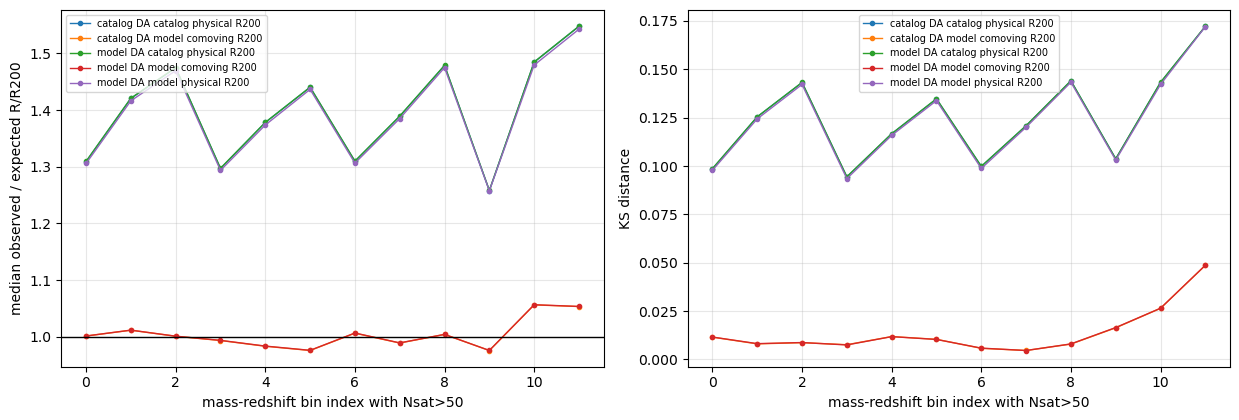

In [13]:

geom = agh.model_geometry_for_catalog(model_ref, halo_catalog)
active_halo_mask = (
    (np.asarray(halo_catalog['z'], dtype=np.float64) >= z_range[0])
    & (np.asarray(halo_catalog['z'], dtype=np.float64) < z_range[1])
    & (hod_weights['nsat'] > 0)
)
quantiles = [0.01, 0.05, 0.16, 0.50, 0.84, 0.95, 0.99]
geom_rows = []
for key in ['R200c_catalog_physical_over_model_comoving', 'R200c_catalog_physical_over_model_physical', 'DA_catalog_over_model']:
    vals = np.asarray(geom[key], dtype=np.float64)[active_halo_mask]
    row = {'quantity': key, 'n_active': int(np.count_nonzero(np.isfinite(vals)))}
    for q, v in zip(quantiles, np.nanquantile(vals, quantiles)):
        row[f'q{int(q*100):02d}'] = float(v)
    geom_rows.append(row)
geom_quantile_df = pd.DataFrame(geom_rows)
display(geom_quantile_df)

rr_catalog = np.asarray(parent_match['rr200'], dtype=np.float64)
rr_model_comoving_both = agh.satellite_rr200_with_geometry(galaxies, halo_catalog, parent_match, geom['DA_model_hMpc'], geom['R200c_model_comoving_hMpc'])
rr_model_da_catalog_r200 = agh.satellite_rr200_with_geometry(galaxies, halo_catalog, parent_match, geom['DA_model_hMpc'], geom['R200c_catalog_hMpc'])
rr_catalog_da_model_comoving_r200 = agh.satellite_rr200_with_geometry(galaxies, halo_catalog, parent_match, geom['DA_catalog_hMpc'], geom['R200c_model_comoving_hMpc'])
rr_model_physical_both = agh.satellite_rr200_with_geometry(galaxies, halo_catalog, parent_match, geom['DA_model_hMpc'], geom['R200c_model_physical_hMpc'])
rr_variants = {
    'catalog_DA_catalog_physical_R200': rr_catalog,
    'model_DA_catalog_physical_R200': rr_model_da_catalog_r200,
    'catalog_DA_model_comoving_R200': rr_catalog_da_model_comoving_r200,
    'model_DA_model_comoving_R200': rr_model_comoving_both,
    'model_DA_model_physical_R200': rr_model_physical_both,
}

radius_rows = []
for im, mbin in enumerate(MASS_BINS):
    for iz, zc in enumerate(PROFILE_Z_CENTERS):
        zbin = (max(0.0, zc - PROFILE_Z_HALF_WIDTH), min(0.5, zc + PROFILE_Z_HALF_WIDTH))
        logm_mid = 0.5 * (mbin[0] + min(mbin[1], 15.6))
        exp = agh.expected_projected_satellite_hist(
            model_ref,
            logm=logm_mid,
            z=zc,
            radial_edges_r200=PROFILE_RADIAL_EDGES_R200,
            n_samples=PROFILE_EXPECTED_SAMPLES,
            seed=9300 + 10 * im + iz,
            include_samples=True,
        )
        for name, rr in rr_variants.items():
            obs = agh.stack_satellite_rr200_by_parent(halo_catalog, parent_match, rr, PROFILE_RADIAL_EDGES_R200, logm_range=mbin, z_range=zbin)
            metrics = agh.radial_distribution_metrics(obs['rr200'], exp['rr200'])
            radius_rows.append({
                'geometry': name,
                'logM_lo': mbin[0],
                'logM_hi': mbin[1],
                'z_center': zc,
                'n_sat': obs['n_sat_matched'],
                **metrics,
            })
radius_geometry_df = pd.DataFrame(radius_rows)
display(radius_geometry_df)

summary_geometry_df = (
    radius_geometry_df[radius_geometry_df['n_sat'] > 50]
    .groupby('geometry')[['median_ratio', 'q68_ratio', 'ks_distance']]
    .median()
    .reset_index()
)
display(summary_geometry_df)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
for geom_name, sub in radius_geometry_df[radius_geometry_df['n_sat'] > 50].groupby('geometry'):
    x = np.arange(len(sub))
    label = geom_name.replace('_', ' ')
    axes[0].plot(x, sub['median_ratio'].to_numpy(), marker='.', lw=1.0, label=label)
    axes[1].plot(x, sub['ks_distance'].to_numpy(), marker='.', lw=1.0, label=label)
axes[0].axhline(1.0, color='k', lw=1)
axes[0].set_ylabel('median observed / expected R/R200')
axes[1].set_ylabel('KS distance')
for ax in axes:
    ax.set_xlabel('mass-redshift bin index with Nsat>50')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


## HOD Realization, Pair Moments, And Satellite Cap

The cap can suppress high-occupation halos and small-scale pairs.  It cannot produce a positive large-scale satellite-weighted clustering excess, but it can matter for small-scale profile validation.


,z_lo,z_hi,logM_lo,logM_hi,n_halos,actual_cen,pred_cen,actual_sat,pred_sat,actual_tot,pred_tot,cen_over_pred,sat_over_pred,tot_over_pred
0,0.00,0.15,14.00,14.25,4957,0,0.418643,0,0.000000,0,0.418643,0.000000,NaN,0.000000
1,0.00,0.15,14.25,14.50,1989,0,0.318151,0,0.000000,0,0.318151,0.000000,NaN,0.000000
2,0.00,0.15,14.50,15.00,847,0,0.256668,0,0.000000,0,0.256668,0.000000,NaN,0.000000
3,0.00,0.15,15.00,16.00,37,0,0.027071,0,0.000000,0,0.027071,0.000000,NaN,0.000000
4,0.15,0.25,14.00,14.25,13931,1,15.780337,0,0.090083,1,15.870420,0.063370,0.000000,0.063010
5,0.15,0.25,14.25,14.50,5284,1,8.054266,0,0.514645,1,8.568911,0.124158,0.000000,0.116701
6,0.15,0.25,14.50,15.00,2127,1,4.907199,0,3.227927,1,8.135127,0.203782,0.000000,0.122924
7,0.15,0.25,15.00,16.00,92,0,0.315060,0,1.496348,0,1.811408,0.000000,0.000000,0.000000
8,0.25,0.35,14.00,14.25,24109,20401,18659.575246,16233,17176.412466,36634,35835.987712,1.093326,0.945075,1.022268
9,0.25,0.35,14.25,14.50,8736,7435,7424.663904,16268,17094.208839,23703,24518.872743,1.001392,0.951667,0.966725


,z_lo,z_hi,logM_lo,logM_hi,n_halos,actual_cen,actual_sat,pred_cen,pred_sat,actual_cs_ordered,...,actual_ss_ordered,pred_ss_poisson_ordered,pred_ss_same_gal_included,actual_pair_total,pred_pair_total_poisson,pred_pair_total_same_gal_included,cs_over_pred,ss_over_pred_poisson,pair_over_pred_poisson,pair_over_pred_same_gal_included
0,0.00,0.15,14.00,14.25,4957,0,0,0.418643,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN
1,0.00,0.15,14.25,14.50,1989,0,0,0.318151,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN
2,0.00,0.15,14.50,15.00,847,0,0,0.256668,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN
3,0.00,0.15,15.00,16.00,37,0,0,0.027071,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN
4,0.15,0.25,14.00,14.25,13931,1,0,15.780337,0.090083,0.0,...,0.0,0.000038,0.090121,0.0,0.006432,0.096515,0.000000,0.000000,0.000000,0.000000
5,0.15,0.25,14.25,14.50,5284,1,0,8.054266,0.514645,0.0,...,0.0,0.002882,0.517526,0.0,0.048425,0.563070,0.000000,0.000000,0.000000,0.000000
6,0.15,0.25,14.50,15.00,2127,1,0,4.907199,3.227927,0.0,...,0.0,0.264084,3.492011,0.0,0.642367,3.870294,0.000000,0.000000,0.000000,0.000000
7,0.15,0.25,15.00,16.00,92,0,0,0.315060,1.496348,0.0,...,0.0,0.750251,2.246598,0.0,0.997384,2.493732,0.000000,0.000000,0.000000,0.000000
8,0.25,0.35,14.00,14.25,24109,20401,16233,18659.575246,17176.412466,29616.0,...,14028.0,15427.940137,32604.352602,43644.0,45064.298332,62240.710798,0.999313,0.909259,0.968483,0.701213
9,0.25,0.35,14.25,14.50,8736,7435,16268,7424.663904,17094.208839,29816.0,...,35784.0,39561.759145,56655.967983,65600.0,70780.883104,87875.091943,0.955056,0.904510,0.926804,0.746514


,max_mean_nsat,max_gals_per_halo,safe_max_gals_per_halo,max_tail_probability,mean_tail_probability,safe_max_tail_probability,safe_mean_tail_probability
0,609.983127,637,858,0.1417,0.000226,1.786073e-21,1.239745e-24


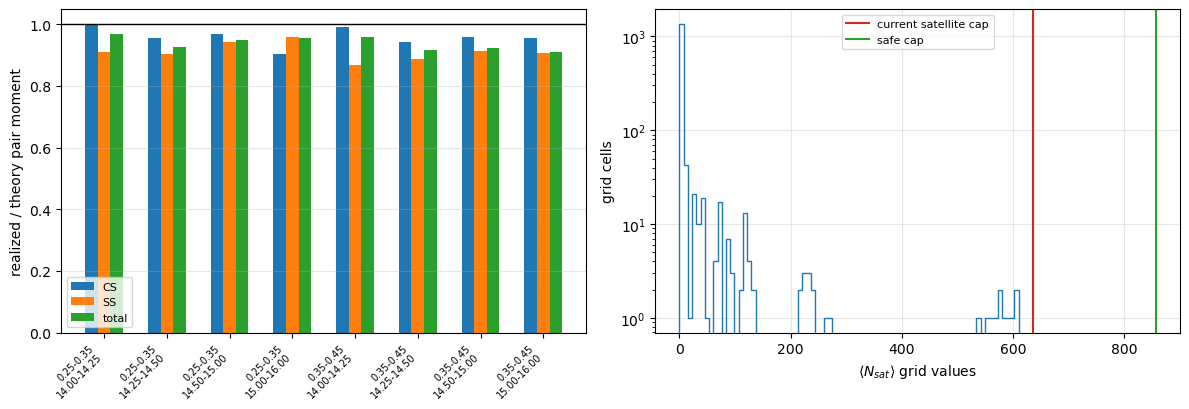

In [11]:
hod_df = pd.DataFrame(agh.hod_occupation_comparison(halo_catalog, galaxies, model_ref, z_edges=z_edges_diag, logm_edges=logm_edges_diag))
display(hod_df)
display(pair_df)

trunc = agh.satellite_truncation_summary(model_ref)
trunc_display = {k: v for k, v in trunc.items() if 'grid' not in k}
display(pd.DataFrame([trunc_display]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
pair_plot = pair_df[(pair_df['z_hi'] > z_range[0]) & (pair_df['z_lo'] < z_range[1])].copy()
x = np.arange(len(pair_plot))
labels = [f'{r.z_lo:.2f}-{r.z_hi:.2f}\n{r.logM_lo:.2f}-{r.logM_hi:.2f}' for r in pair_plot.itertuples()]
axes[0].bar(x - 0.2, pair_plot['cs_over_pred'], width=0.2, label='CS')
axes[0].bar(x, pair_plot['ss_over_pred_poisson'], width=0.2, label='SS')
axes[0].bar(x + 0.2, pair_plot['pair_over_pred_poisson'], width=0.2, label='total')
axes[0].axhline(1, color='k', lw=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('realized / theory pair moment')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

nsat_grid = np.asarray(model_ref.profiles.Nsat_mat, dtype=np.float64)
axes[1].hist(nsat_grid.ravel(), bins=80, histtype='step')
axes[1].axvline(trunc['max_gals_per_halo'] - 1, color='tab:red', label='current satellite cap')
axes[1].axvline(trunc['safe_max_gals_per_halo'] - 1, color='tab:green', label='safe cap')
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$\langle N_{sat}\rangle$ grid values')
axes[1].set_ylabel('grid cells')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()



## Small-Scale One-Halo `gg` Diagnostics

This is the direct test for the `ell~1000` question.  The map `gg` excess can come from three different places: a real same-halo pair excess, the satellite radial profile, or the analytic transition/response model suppressing the theory.  The direct pair estimator below computes the same-parent contribution from the generated galaxy catalog without HEALPix, split into central-satellite and satellite-satellite terms.


measuring generated gg at nside 1024
direct same-halo pair ell count: 109 ell max: 2600


,n_gal,n_groups,ordered_pairs,ordered_cs,ordered_ss,shot
0,152180,38868,449538.0,174092.0,275446.0,0.000083


,ell_lo,ell_hi,gg_meas_over_stored_total,gg_meas_over_sum_raw,gg_meas_over_sum_response,direct_1h_over_1h_raw,direct_1h_over_1h_response,direct_cs_over_raw_1h,direct_ss_over_raw_1h,direct_cs_over_cs_raw,direct_ss_over_ss_raw,direct_cs_over_cs_response,direct_ss_over_ss_response,one_halo_fraction_raw,one_halo_fraction_response
0,80,300,1.285870,1.126961,1.285870,1.162517,1.319269,0.467788,0.694729,1.149101,1.176263,1.303251,1.335374,0.687875,0.687558
1,300,700,1.371378,1.177836,1.371378,1.163788,1.356395,0.536605,0.627183,1.150661,1.180762,1.341779,1.375634,0.938037,0.938158
2,700,1200,1.325281,1.168930,1.325281,1.162166,1.321339,0.650090,0.512076,1.152018,1.183333,1.310716,1.344442,0.983443,0.983548
3,1200,2000,1.304788,1.197909,1.304788,1.159595,1.264575,0.773638,0.385957,1.154063,1.182080,1.258918,1.288643,0.994401,0.994444
4,2000,2600,1.321734,1.238759,1.321734,1.159298,1.237020,0.866770,0.292528,1.158044,1.177506,1.235758,1.256504,0.997463,0.997479


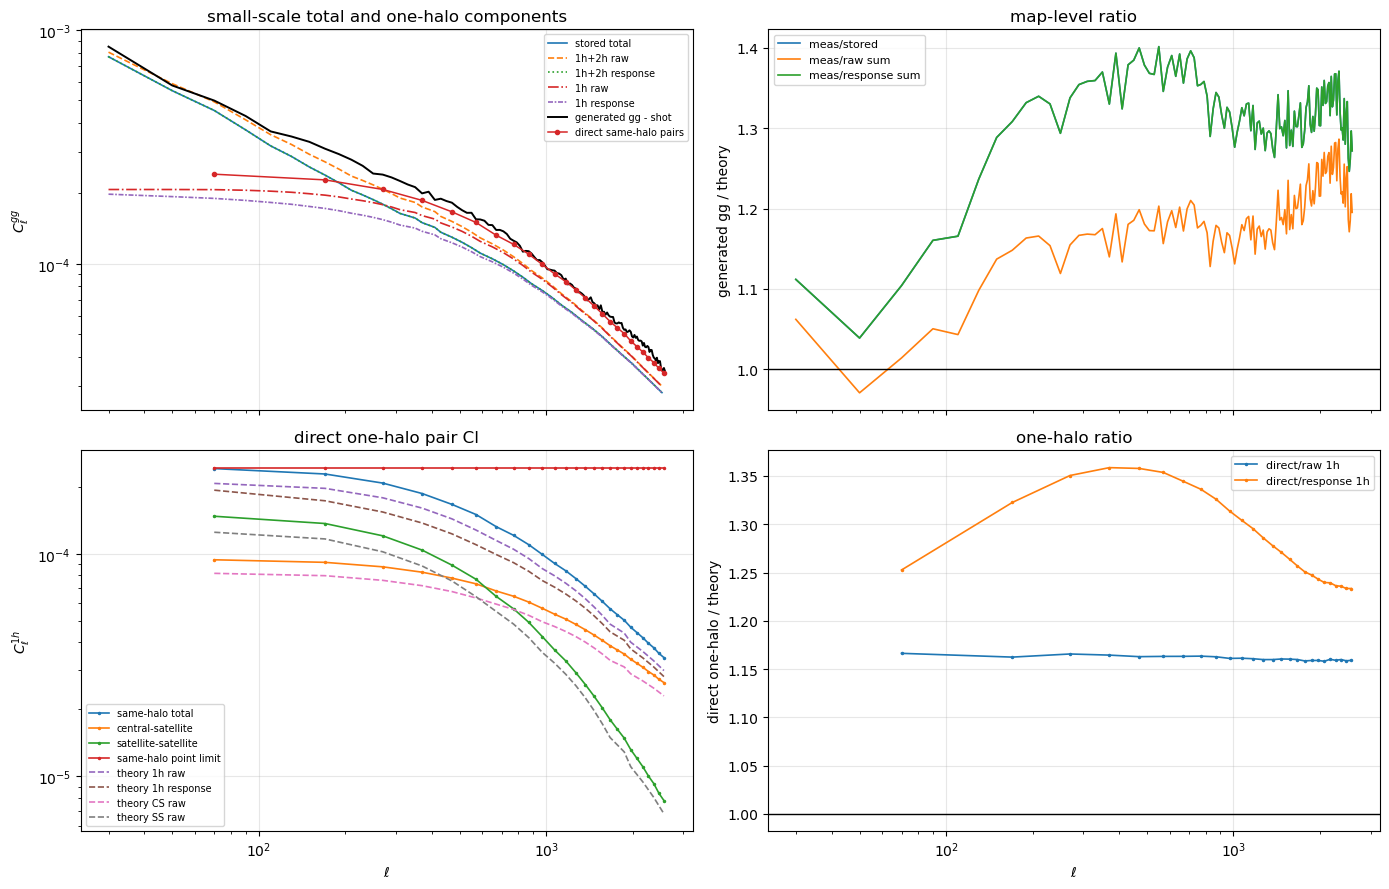

Interpretation rule: if direct_1h_over_1h_raw is near unity but gg_meas_over_stored_total is high, the small-scale issue is mainly the transition/response total theory, not satellite placement.


In [18]:

SMALL_SCALE_NSIDE = MAP_NSIDE
SMALL_ELL_MAX = min(2600, 3 * SMALL_SCALE_NSIDE - 1)
SMALL_RANGES = [(80, 300), (300, 700), (700, 1200), (1200, 2000), (2000, SMALL_ELL_MAX)]

print('measuring generated gg at nside', SMALL_SCALE_NSIDE)
cls_generated_small = agh.measure_weighted_cls({}, galaxies, SMALL_SCALE_NSIDE, z_range=z_range, pixwin_correction=True)
pgg_decomp = agh.pgg_decomposition_cls(model_ref, COMPARE_BIN)

ell_pair = np.unique(np.concatenate([
    np.arange(50, SMALL_ELL_MAX + 1, 50),
    np.rint(np.asarray(pgg_decomp['ell'], dtype=np.float64)).astype(np.int64),
]))
ell_pair = ell_pair[(ell_pair >= 20) & (ell_pair <= SMALL_ELL_MAX)]
print('direct same-halo pair ell count:', len(ell_pair), 'ell max:', ell_pair[-1])
pair_1h = agh.same_halo_pair_cls(galaxies, ell_pair, z_range=z_range)
display(pd.DataFrame([{k: v for k, v in pair_1h.items() if np.isscalar(v)}]))

def interp_on(ell, src_ell, src_val):
    return np.interp(np.asarray(ell, dtype=np.float64), np.asarray(src_ell, dtype=np.float64), np.asarray(src_val, dtype=np.float64), left=np.nan, right=np.nan)

def ratio_summary(label, ell_num, num, ell_den, den, lo, hi):
    den_on = interp_on(ell_num, ell_den, den)
    mask = (ell_num >= lo) & (ell_num < hi) & np.isfinite(num) & np.isfinite(den_on) & (den_on != 0)
    ratio = np.asarray(num)[mask] / den_on[mask]
    return float(np.nanmean(ratio)) if np.any(mask) else np.nan

ell_map = np.asarray(cls_generated_small['ell'], dtype=np.float64)
gg_meas = np.asarray(cls_generated_small['gg_without_shot'], dtype=np.float64)
ell_th = np.asarray(pgg_decomp['ell'], dtype=np.float64)
small_rows = []
for lo, hi in SMALL_RANGES:
    row = {'ell_lo': lo, 'ell_hi': hi}
    row['gg_meas_over_stored_total'] = ratio_summary('measured/stored', ell_map, gg_meas, ell_th, pgg_decomp['cls']['stored_total'], lo, hi)
    row['gg_meas_over_sum_raw'] = ratio_summary('measured/raw_sum', ell_map, gg_meas, ell_th, pgg_decomp['cls']['sum_raw'], lo, hi)
    row['gg_meas_over_sum_response'] = ratio_summary('measured/response_sum', ell_map, gg_meas, ell_th, pgg_decomp['cls']['sum_response'], lo, hi)
    row['direct_1h_over_1h_raw'] = ratio_summary('direct/raw1h', pair_1h['ell'], pair_1h['cl_1h'], ell_th, pgg_decomp['cls']['1h_raw'], lo, hi)
    row['direct_1h_over_1h_response'] = ratio_summary('direct/resp1h', pair_1h['ell'], pair_1h['cl_1h'], ell_th, pgg_decomp['cls']['1h_response'], lo, hi)
    row['direct_cs_over_raw_1h'] = ratio_summary('direct_cs/raw1h', pair_1h['ell'], pair_1h['cl_cs'], ell_th, pgg_decomp['cls']['1h_raw'], lo, hi)
    row['direct_ss_over_raw_1h'] = ratio_summary('direct_ss/raw1h', pair_1h['ell'], pair_1h['cl_ss'], ell_th, pgg_decomp['cls']['1h_raw'], lo, hi)
    row['direct_cs_over_cs_raw'] = ratio_summary('direct_cs/csraw', pair_1h['ell'], pair_1h['cl_cs'], ell_th, pgg_decomp['cls']['1h_cs_raw'], lo, hi)
    row['direct_ss_over_ss_raw'] = ratio_summary('direct_ss/ssraw', pair_1h['ell'], pair_1h['cl_ss'], ell_th, pgg_decomp['cls']['1h_ss_raw'], lo, hi)
    row['direct_cs_over_cs_response'] = ratio_summary('direct_cs/csresp', pair_1h['ell'], pair_1h['cl_cs'], ell_th, pgg_decomp['cls']['1h_cs_response'], lo, hi)
    row['direct_ss_over_ss_response'] = ratio_summary('direct_ss/ssresp', pair_1h['ell'], pair_1h['cl_ss'], ell_th, pgg_decomp['cls']['1h_ss_response'], lo, hi)
    row['one_halo_fraction_raw'] = ratio_summary('1h/rawsum', ell_th, pgg_decomp['cls']['1h_raw'], ell_th, pgg_decomp['cls']['sum_raw'], lo, hi)
    row['one_halo_fraction_response'] = ratio_summary('1h/respsum', ell_th, pgg_decomp['cls']['1h_response'], ell_th, pgg_decomp['cls']['sum_response'], lo, hi)
    small_rows.append(row)
small_scale_df = pd.DataFrame(small_rows)
display(small_scale_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex='col')
ax = axes[0, 0]
for key, label, style in [
    ('stored_total', 'stored total', '-'),
    ('sum_raw', '1h+2h raw', '--'),
    ('sum_response', '1h+2h response', ':'),
    ('1h_raw', '1h raw', '-.'),
    ('1h_response', '1h response', (0, (3, 1, 1, 1))),
]:
    b = psh.bin_spectrum(ell_th, pgg_decomp['cls'][key], ell_min=ELL_MIN, ell_max=SMALL_ELL_MAX, delta_ell=DELTA_ELL)
    ax.plot(b['ell'], b['value'], lw=1.2, ls=style, label=label)
b_meas = psh.bin_spectrum(ell_map, gg_meas, ell_min=ELL_MIN, ell_max=SMALL_ELL_MAX, delta_ell=DELTA_ELL)
ax.plot(b_meas['ell'], b_meas['value'], color='k', lw=1.4, label='generated gg - shot')
b_pair = psh.bin_spectrum(pair_1h['ell'], pair_1h['cl_1h'], ell_min=ELL_MIN, ell_max=SMALL_ELL_MAX, delta_ell=100)
ax.plot(b_pair['ell'], b_pair['value'], color='tab:red', marker='.', lw=1.1, label='direct same-halo pairs')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel(r'$C_\ell^{gg}$')
ax.set_title('small-scale total and one-halo components')
ax.grid(alpha=0.3)
ax.legend(fontsize=7)

ax = axes[0, 1]
for den_key, label in [('stored_total', 'meas/stored'), ('sum_raw', 'meas/raw sum'), ('sum_response', 'meas/response sum')]:
    den = interp_on(ell_map, ell_th, pgg_decomp['cls'][den_key])
    bp = psh.bin_spectrum_pair(ell_map, gg_meas, den, ell_min=ELL_MIN, ell_max=SMALL_ELL_MAX, delta_ell=DELTA_ELL)
    ax.plot(bp['ell'], bp['ratio'], lw=1.2, label=label)
ax.axhline(1, color='k', lw=1)
ax.set_xscale('log')
ax.set_ylabel('generated gg / theory')
ax.set_title('map-level ratio')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1, 0]
for val_key, label in [('cl_1h', 'same-halo total'), ('cl_cs', 'central-satellite'), ('cl_ss', 'satellite-satellite'), ('cl_1h_point', 'same-halo point limit')]:
    b = psh.bin_spectrum(pair_1h['ell'], pair_1h[val_key], ell_min=ELL_MIN, ell_max=SMALL_ELL_MAX, delta_ell=100)
    ax.plot(b['ell'], b['value'], lw=1.2, marker='.', ms=3, label=label)
for key, label in [('1h_raw', 'theory 1h raw'), ('1h_response', 'theory 1h response'), ('1h_cs_raw', 'theory CS raw'), ('1h_ss_raw', 'theory SS raw')]:
    b = psh.bin_spectrum(ell_th, pgg_decomp['cls'][key], ell_min=ELL_MIN, ell_max=SMALL_ELL_MAX, delta_ell=100)
    ax.plot(b['ell'], b['value'], lw=1.2, ls='--', label=label)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$C_\ell^{1h}$')
ax.set_title('direct one-halo pair Cl')
ax.grid(alpha=0.3)
ax.legend(fontsize=7)

ax = axes[1, 1]
for den_key, label in [('1h_raw', 'direct/raw 1h'), ('1h_response', 'direct/response 1h')]:
    den = interp_on(pair_1h['ell'], ell_th, pgg_decomp['cls'][den_key])
    bp = psh.bin_spectrum_pair(pair_1h['ell'], pair_1h['cl_1h'], den, ell_min=ELL_MIN, ell_max=SMALL_ELL_MAX, delta_ell=100)
    ax.plot(bp['ell'], bp['ratio'], marker='.', ms=3, lw=1.2, label=label)
ax.axhline(1, color='k', lw=1)
ax.set_xscale('log')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel('direct one-halo / theory')
ax.set_title('one-halo ratio')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print('Interpretation rule: if direct_1h_over_1h_raw is near unity but gg_meas_over_stored_total is high, the small-scale issue is mainly the transition/response total theory, not satellite placement.')


## Evidence-Based Interpretation

The table below turns the diagnostics into concrete next actions.  Re-run this cell after the notebook above completes.


In [17]:

def value_from(df, label_contains, col='mean_ratio'):
    sub = df[df['diagnostic'].str.contains(label_contains, regex=False)]
    return float(sub[col].iloc[0]) if len(sub) else np.nan

pasted_ratio = value_from(recap_df, 'pasted generated gg')
cen_ratio = value_from(recap_df, 'Ncen parent map')
sat_u1_ratio = value_from(surgery_df, 'Nsat / sat u=1')
sat_u_ratio = value_from(surgery_df, 'Nsat / sat u_clm')
tot_u1_ratio = value_from(surgery_df, 'Ntot / total u=1')
tot_u_ratio = value_from(surgery_df, 'Ntot / total u_clm')
profile_ks = float(np.nanmedian(profile_df.loc[profile_df['n_sat'] > 50, 'ks_distance'])) if np.any(profile_df['n_sat'] > 50) else np.nan
profile_med = float(np.nanmedian(profile_df.loc[profile_df['n_sat'] > 50, 'median_ratio'])) if np.any(profile_df['n_sat'] > 50) else np.nan
pair_ratio = float(pair_summary['pair_over_pred_poisson'].iloc[0])

if 'matter_bias_df' in globals():
    matter_tot_bias_ratio = float(matter_bias_df.loc[matter_bias_df['field'] == 'total point', 'mean_empirical_over_theory'].iloc[0])
    matter_sat_bias_ratio = float(matter_bias_df.loc[matter_bias_df['field'] == 'satellite point', 'mean_empirical_over_theory'].iloc[0])
else:
    matter_tot_bias_ratio = np.nan
    matter_sat_bias_ratio = np.nan

if 'matched_window_bias_df' in globals() and len(matched_window_bias_df):
    matched_tot_bias_ratio = float(matched_window_bias_df.loc[matched_window_bias_df['field'] == 'ntot', 'mean_empirical_over_theory'].iloc[0])
    matched_sat_bias_ratio = float(matched_window_bias_df.loc[matched_window_bias_df['field'] == 'nsat', 'mean_empirical_over_theory'].iloc[0])
else:
    matched_tot_bias_ratio = np.nan
    matched_sat_bias_ratio = np.nan

if 'summary_geometry_df' in globals() and len(summary_geometry_df):
    def geometry_metric(name, col):
        sub = summary_geometry_df[summary_geometry_df['geometry'] == name]
        return float(sub[col].iloc[0]) if len(sub) else np.nan
    radius_catalog_med = geometry_metric('catalog_DA_catalog_physical_R200', 'median_ratio')
    radius_model_med = geometry_metric('model_DA_model_comoving_R200', 'median_ratio')
    radius_catalog_ks = geometry_metric('catalog_DA_catalog_physical_R200', 'ks_distance')
    radius_model_ks = geometry_metric('model_DA_model_comoving_R200', 'ks_distance')
else:
    radius_catalog_med = profile_med
    radius_model_med = np.nan
    radius_catalog_ks = profile_ks
    radius_model_ks = np.nan

rows = [
    {
        'hypothesis': 'general estimator/window/HMF problem',
        'evidence': f'Ncen ratio={cen_ratio:.2f}; pasted gg ratio={pasted_ratio:.2f}',
        'status': 'disfavored' if np.isfinite(cen_ratio) and abs(cen_ratio - 1) < 0.15 else 'still possible',
        'next_fix': 'Do not change estimator unless central ratio also fails.'
    },
    {
        'hypothesis': 'excess one-halo pair moments',
        'evidence': f'pair ratio={pair_ratio:.2f}',
        'status': 'disfavored' if np.isfinite(pair_ratio) and pair_ratio < 1.1 else 'possible',
        'next_fix': 'Pair moments are not the cause if ratio is <=1.'
    },
    {
        'hypothesis': 'satellite Fourier profile u_clm over-suppresses theory',
        'evidence': f'Nsat/u_clm={sat_u_ratio:.2f}, Nsat/u1={sat_u1_ratio:.2f}; Ntot/u_clm={tot_u_ratio:.2f}, Ntot/u1={tot_u1_ratio:.2f}',
        'status': 'favored' if np.isfinite(sat_u_ratio) and np.isfinite(sat_u1_ratio) and abs(sat_u1_ratio - 1) < abs(sat_u_ratio - 1) else 'not sufficient',
        'next_fix': 'Inspect uk_clm/radius convention before changing production theory.'
    },
    {
        'hypothesis': 'Abacus satellite-weighted halo bias is high even for point satellites',
        'evidence': f'Nsat/u1={sat_u1_ratio:.2f}, Ntot/u1={tot_u1_ratio:.2f}',
        'status': 'favored' if np.isfinite(sat_u1_ratio) and sat_u1_ratio > 1.15 else 'disfavored',
        'next_fix': 'Use particle-shell matter bias test to decide whether this is analytic bias/projection mismatch or lightcone variance.'
    },
    {
        'hypothesis': 'theory effective halo bias is low relative to Abacus matter',
        'evidence': f'top-hat empirical/theory b_sat={matter_sat_bias_ratio:.2f}, b_tot={matter_tot_bias_ratio:.2f}; matched-window b_sat={matched_sat_bias_ratio:.2f}, b_tot={matched_tot_bias_ratio:.2f}',
        'status': 'favored' if np.isfinite(matched_tot_bias_ratio) and matched_tot_bias_ratio > 1.08 else ('top-hat estimator mismatch likely' if np.isfinite(matter_tot_bias_ratio) and matter_tot_bias_ratio > 1.08 else 'disfavored or not run'),
        'next_fix': 'If favored, compare against z<1 logM>12.5 and only then consider an Abacus-specific bias calibration.'
    },
    {
        'hypothesis': 'generated satellite radii are inconsistent with profile CDF',
        'evidence': f'catalog physical-R200 median={radius_catalog_med:.2f}, KS={radius_catalog_ks:.2f}; GODMAX comoving-R200 median={radius_model_med:.2f}, KS={radius_model_ks:.2f}',
        'status': 'favored' if np.isfinite(radius_model_med) and (abs(radius_model_med - 1) > 0.2 or radius_model_ks > 0.2) else ('diagnostic convention mismatch likely' if np.isfinite(radius_model_med) and np.isfinite(radius_catalog_med) and abs(radius_catalog_med - 1) > abs(radius_model_med - 1) + 0.1 else 'not obvious'),
        'next_fix': 'If GODMAX geometry fixes it, update diagnostics; if not, inspect get_sim_maps.py satellite radius units.'
    },
]
interpretation_df = pd.DataFrame(rows)
display(interpretation_df)

print('Use this notebook to pick the next code fix. Do not modify GODMAX src until one favored row has stable evidence at NSIDE_DIAG=512 and preferably NSIDE_DIAG=1024.')


,hypothesis,evidence,status,next_fix
0,general estimator/window/HMF problem,Ncen ratio=1.23; pasted gg ratio=1.29,still possible,Do not change estimator unless central ratio a...
1,excess one-halo pair moments,pair ratio=0.94,disfavored,Pair moments are not the cause if ratio is <=1.
2,satellite Fourier profile u_clm over-suppresse...,"Nsat/u_clm=1.42, Nsat/u1=1.29; Ntot/u_clm=1.34...",favored,Inspect uk_clm/radius convention before changi...
3,Abacus satellite-weighted halo bias is high ev...,"Nsat/u1=1.29, Ntot/u1=1.26",favored,Use particle-shell matter bias test to decide ...
4,theory effective halo bias is low relative to ...,"top-hat empirical/theory b_sat=1.48, b_tot=1.4...",favored,"If favored, compare against z<1 logM>12.5 and ..."
5,generated satellite radii are inconsistent wit...,"catalog physical-R200 median=1.40, KS=0.12; GO...",diagnostic convention mismatch likely,"If GODMAX geometry fixes it, update diagnostic..."


Use this notebook to pick the next code fix. Do not modify GODMAX src until one favored row has stable evidence at NSIDE_DIAG=512 and preferably NSIDE_DIAG=1024.
